# Type3 - added attention, Optuna, GloVe, and bidirection in recurrent models

# 1. EDA AND PREPROCESSING

In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
import unicodedata
warnings.filterwarnings('ignore')
from wordcloud import WordCloud
import nltk
from nltk import pos_tag, word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
from collections import Counter
import unicodedata
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score
import time
from sklearn.utils.class_weight import compute_class_weight
import optuna
from optuna.trial import Trial





sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


If you use Colab

In [ ]:
# from google.colab import files
# uploaded = files.upload()  # upload bitcoin_tweets.csv
# DATA_PATH = 'tweets.csv'

Saving tweets.csv to tweets.csv


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
DATA_PATH = './tweets.csv'

df = pd.read_csv(DATA_PATH, lineterminator='\n')
df.columns = df.columns.str.strip()

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 76,797 rows x 9 columns


,token,date,reply_count,like_count,retweet_count,quote_count,text,sentiment_label,sentiment_score
0,bitcoin,2022-01-01 00:00:00.000,20,207,31,3,Most people underestimate the impact #Bitcoin ...,Neutral,0.717482
1,bitcoin,2022-01-01 00:00:00.000,232,3405,286,27,#Bitcoin has started a new yearly candle https...,Neutral,0.810814
2,bitcoin,2022-01-01 00:00:00.000,2,861,12,0,@DESTROYBINARY did people forget that the amog...,Neutral,0.606978
3,bitcoin,2022-01-01 00:00:00.000,18,306,30,9,"In 2017, miners attempted to assert control ov...",Negative,0.510956
4,bitcoin,2022-01-01 00:00:00.000,35,721,35,1,Yearly Close \nMonthly Close\nDaily Close\n\nh...,Positive,0.988296


In [6]:
print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')


=== Data types ===
token               object
date                object
reply_count          int64
like_count           int64
retweet_count        int64
quote_count          int64
text                object
sentiment_label     object
sentiment_score    float64
dtype: object

=== Shape ===
Rows: 76,797  |  Columns: 9


In [7]:
print('=== Statistical summary ===')
df.describe(include='all').T

=== Statistical summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
token,76797,1,bitcoin,76797,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,76797,538,2022-11-27 00:00:00.000,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reply_count,76797.0,NaN,NaN,NaN,147.446398,567.192383,0.0,21.0,58.0,154.0,62452.0
like_count,76797.0,NaN,NaN,NaN,1250.952967,3262.550493,0.0,182.0,473.0,1296.0,383127.0
retweet_count,76797.0,NaN,NaN,NaN,284.166322,1758.528126,0.0,29.0,77.0,207.0,116064.0
quote_count,76797.0,NaN,NaN,NaN,19.698009,277.474438,0.0,1.0,4.0,14.0,45401.0
text,76797,75955,Drop your #Bitcoin or #BNB address below and m...,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_label,76797,3,Neutral,42104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_score,76797.0,NaN,NaN,NaN,0.713486,0.141153,0.340653,0.59243,0.710502,0.833887,0.993558


It is evident that the number of unique text entries is lower than the total count, indicating the presence of duplicates (842 instances).

An example of the most frequently occurring duplicate is:

In [8]:
df[df["text"]== 'Drop your #Bitcoin or #BNB address below and make sure you are following me.\n\nDont ask why!']

,token,date,reply_count,like_count,retweet_count,quote_count,text,sentiment_label,sentiment_score
28626,bitcoin,2022-10-09 00:00:00.000,1122,1081,426,13,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
28998,bitcoin,2022-10-11 00:00:00.000,1054,1218,412,4,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
30016,bitcoin,2022-10-16 00:00:00.000,905,881,280,9,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
30392,bitcoin,2022-10-18 00:00:00.000,899,1046,337,5,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
31410,bitcoin,2022-10-23 00:00:00.000,1114,1134,450,9,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
32820,bitcoin,2022-10-30 00:00:00.000,1036,1034,335,12,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
33198,bitcoin,2022-11-01 00:00:00.000,876,1246,386,5,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
34219,bitcoin,2022-11-06 00:00:00.000,1087,1271,387,12,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
34578,bitcoin,2022-11-08 00:00:00.000,1064,846,386,10,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035
35715,bitcoin,2022-11-13 00:00:00.000,1171,1023,380,11,Drop your #Bitcoin or #BNB address below and m...,Neutral,0.742035


In [9]:
TEXT_COL  = 'text'
LABEL_COL = 'sentiment_label'
SCORE_COL = 'sentiment_score'

In [10]:
dupes = df[df.duplicated(subset=[TEXT_COL], keep=False)]
print(f"Total duplicate rows: {len(dupes)}")

conflicting = (
    df.groupby(TEXT_COL)[LABEL_COL]
    .nunique()
    .reset_index()
    .query(f'{LABEL_COL} > 1')
)
print(f"Texts with conflicting labels: {len(conflicting)}")

Total duplicate rows: 1427
Texts with conflicting labels: 14


In [11]:
duped_texts = df[df.duplicated(subset=['text'], keep=False)]['text'].nunique()
print(f"Unique texts involved in duplication: {duped_texts}")

Unique texts involved in duplication: 585


The calculation is consistent: 842 duplicates + 585 unique texts that were multiplied = 1,427.


There remain 14 tweets that are duplicates but possess differing label values.

In [12]:
conflicting_texts = (
    df.groupby('text')['sentiment_label']
    .nunique()
    .reset_index()
    .query('sentiment_label > 1')['text']
)

conflicting_rows = (
    df[df['text'].isin(conflicting_texts)]
    .sort_values('text')
    .reset_index(drop=True)
)

print(f"Total rows involved: {len(conflicting_rows)}")
conflicting_rows[['text', 'sentiment_label', 'sentiment_score']]

Total rows involved: 38


,text,sentiment_label,sentiment_score
0,#BITCOIN BOUNCING BACK! 🚀,Neutral,0.661252
1,#BITCOIN BOUNCING BACK! 🚀,Positive,0.857929
2,#BITCOIN IS BREAKING OUT!!!,Positive,0.559775
3,#BITCOIN IS BREAKING OUT!!!,Negative,0.701680
4,#Bitcoin dominance to the moon,Neutral,0.613728
5,#Bitcoin dominance to the moon,Neutral,0.613728
6,#Bitcoin dominance to the moon,Positive,0.882641
7,#Bitcoin has a 99.98% uptime\n\nHigher than Go...,Negative,0.506629
8,#Bitcoin has a 99.98% uptime\n\nHigher than Go...,Positive,0.552529
9,21m • Forever • #Bitcoin,Neutral,0.806540


Based on the logical correlation between the text and the labels, I have personally determined which samples will be retained:

In [13]:
manual_corrections = {
    "#BITCOIN BOUNCING BACK! 🚀": "Positive",
    "#BITCOIN IS BREAKING OUT!!!":   "Positive",
    "#Bitcoin dominance to the moon": "Positive",
    "#Bitcoin has a 99.98% uptime\n\nHigher than Google\nHigher than Amazon\nHigher than Facebook\nHigher than the US Government\n\nGood luck trying to stop it.":"Positive",
    "21m • Forever • #Bitcoin":"Neutral",
    "As bitcoin crashes, Poilievre vows to find new volatile fad to tie Canadian economy to https://t.co/uFUgT1LNxd":"Negative",
    "Elon Musk buys something SHOCKING every year. 🤔\n\n2021 👉 Bitcoin\n2022 👉 Twitter\n2023 👉 _______":"Negative",
    "FUN FACT: #Bitcoin has a larger market cap than Bank of America.":"Positive",
    "If you FOMO on a green day...\n\nYou won't have enough ammo to FOMO on a red day\n\nIf you must FOMO - choose a red day\n\n#BTC #Crypto #Bitcoin":"Neutral",
    "If your coin has a CEO… it’s not your coin.\n\nBuy #Bitcoin instead.":"Neutral",
    "In 2015, #BTC bottomed 547 days before the Halving\n\nIn 2018, $BTC bottomed 517 days before the Halving (discount March 2020 crash)\n\nIf Bitcoin is going to bottom 517-547 days before the upcoming April 2024 Halving...\n\nThen the bottom will occur in Q4 this year\n\n#Crypto #Bitcoin":"Neutral",
    "No one will buy a second house to rent out after they understand #bitcoin.":"Neutral",
    "Printing money is like peeing your pants to keep warm.":"Neutral",
    "RETWEET if you believe in #bitcoin! 🚀":"Neutral",


}

In [14]:
df = df[~df['text'].isin(conflicting_texts)]

correction_rows = []
for text, correct_label in manual_corrections.items():
    original_row = conflicting_rows[conflicting_rows['text'] == text].iloc[0].copy()
    original_row['sentiment_label'] = correct_label
    correction_rows.append(original_row)

df = pd.concat([df, pd.DataFrame(correction_rows)], ignore_index=True)
df = df.drop_duplicates(subset=['text'])
print(f"Final row count: {len(df):,}")


Final row count: 75,955


In [15]:
print(f"Empty texts    : {(df[TEXT_COL].str.strip() == '').sum()}")
print(f"Null texts     : {df[TEXT_COL].isnull().sum()}")

Empty texts    : 0
Null texts     : 0


In [16]:
label_counts = df[LABEL_COL].value_counts()
label_pct    = df[LABEL_COL].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(pd.DataFrame({'Count': label_counts, 'Percentage (%)': label_pct.round(2)}))
print(f'\nUnique classes: {df[LABEL_COL].nunique()}  ->  {df[LABEL_COL].unique().tolist()}')

=== Class Distribution ===
                 Count  Percentage (%)
sentiment_label                       
Neutral          41584           54.75
Positive         22515           29.64
Negative         11856           15.61

Unique classes: 3  ->  ['Neutral', 'Negative', 'Positive']


-----------------------

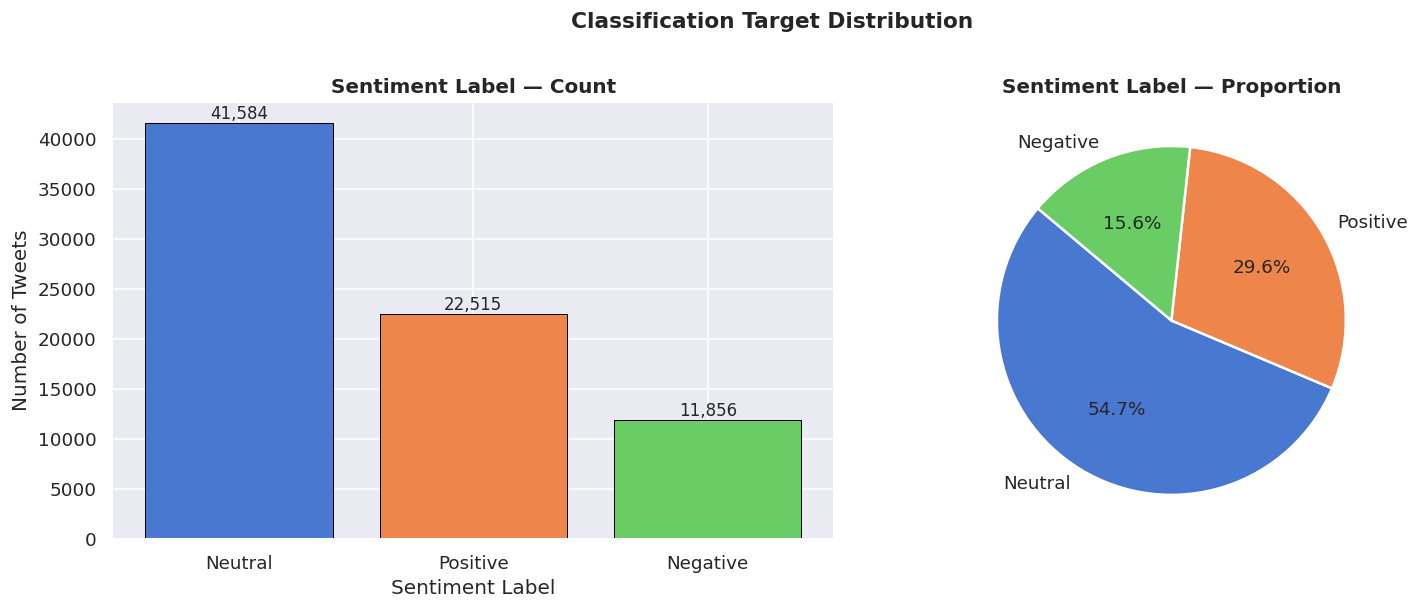

Imbalance ratio (max/min class): 3.51x
Significant imbalance detected. Consider class weighting or oversampling in training.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette('muted', n_colors=len(label_counts))

axes[0].bar(label_counts.index.astype(str), label_counts.values,
            color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Sentiment Label — Count', fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + max(label_counts.values)*0.01, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(
    label_counts.values,
    labels=label_counts.index.astype(str),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sentiment Label — Proportion', fontweight='bold')

plt.suptitle('Classification Target Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

ratio = label_pct.max() / label_pct.min()
print(f'Imbalance ratio (max/min class): {ratio:.2f}x')
if ratio > 3:
    print('Significant imbalance detected. Consider class weighting or oversampling in training.')
else:
    print('Classes are relatively balanced.')

The distribution of labels is naturally occurring; however, the low proportion of the Negative label may pose challenges for the future model in learning patterns associated with this category. Consequently, it is recommended to employ class weighting within the loss function.

In [18]:
score_series = df[SCORE_COL].dropna()

print('=== Sentiment Score Distribution ===')
print(f'\nSkewness : {score_series.skew():.4f}')
print(f'Kurtosis : {score_series.kurt():.4f}')

=== Sentiment Score Distribution ===

Skewness : 0.0513
Kurtosis : -1.1021


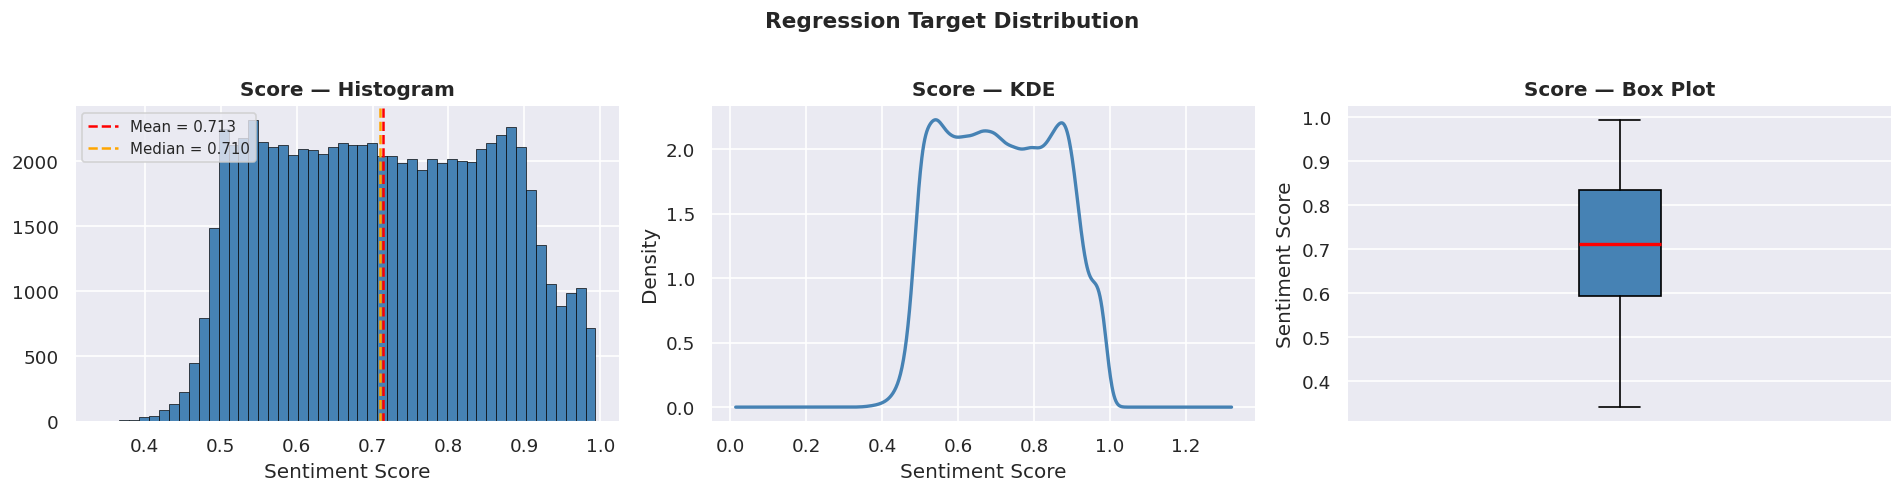

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(score_series, bins=50, color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].axvline(score_series.mean(), color='red', linestyle='--',
                label=f'Mean = {score_series.mean():.3f}')
axes[0].axvline(score_series.median(), color='orange', linestyle='--',
                label=f'Median = {score_series.median():.3f}')
axes[0].set_title('Score — Histogram', fontweight='bold')
axes[0].set_xlabel('Sentiment Score')
axes[0].legend(fontsize=9)

# KDE
score_series.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('Score — KDE', fontweight='bold')
axes[1].set_xlabel('Sentiment Score')

# Box plot
axes[2].boxplot(score_series, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Score — Box Plot', fontweight='bold')
axes[2].set_ylabel('Sentiment Score')
axes[2].set_xticks([])

plt.suptitle('Regression Target Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The bimodal distribution contains two peaks: around 0.55 and 0.85. This indicates the presence of two zones (clusters) in which the model exhibited varying levels of confidence.


Furthermore, the box plot demonstrates an absence of outliers, which is favorable, particularly as the mean and median are located at virtually the same point.

----------------------

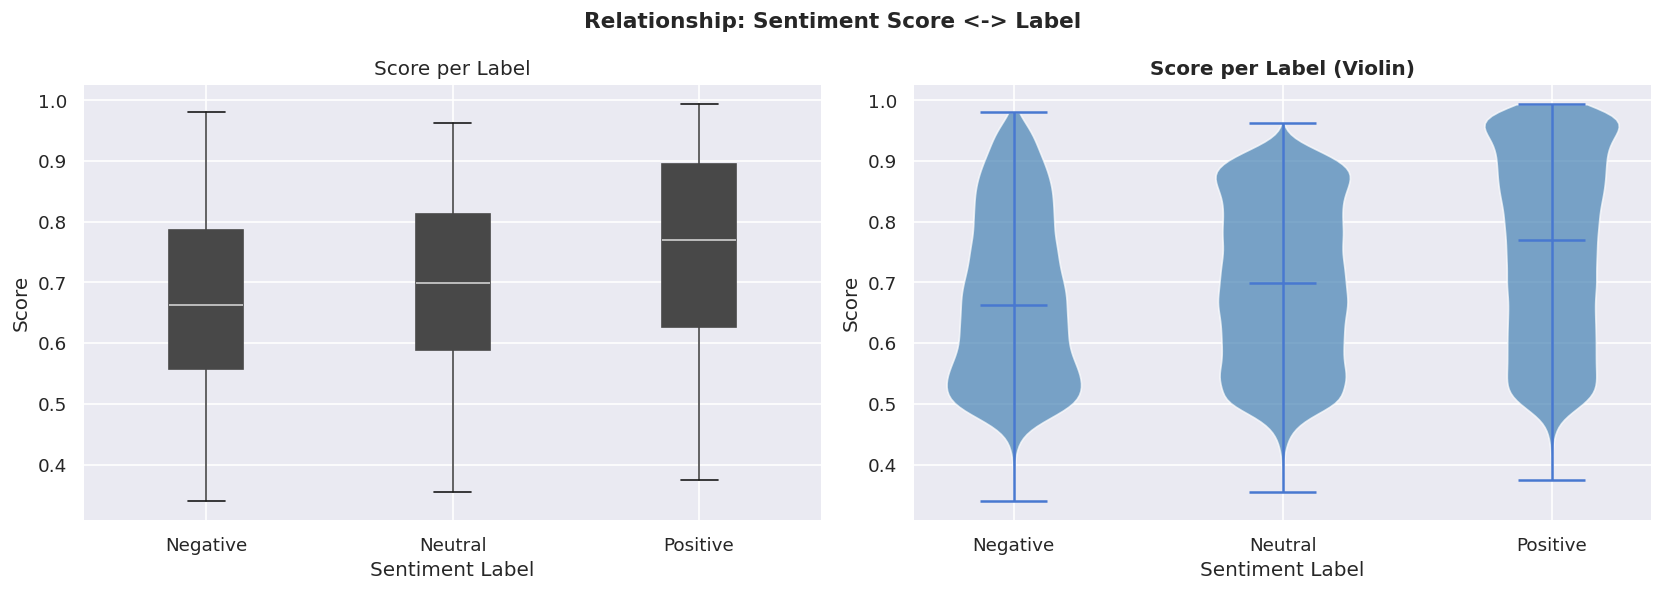

Mean score per class:
                   mean  median     std
sentiment_label                        
Negative         0.6767  0.6625  0.1362
Neutral          0.6992  0.6984  0.1304
Positive         0.7591  0.7698  0.1516


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column=SCORE_COL, by=LABEL_COL, ax=axes[0], patch_artist=True)
axes[0].set_title('Score per Label')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Score')
plt.sca(axes[0]); plt.title('Score per Label')

unique_labels = sorted(df[LABEL_COL].unique())
data_per_label = [df[df[LABEL_COL] == lbl][SCORE_COL].dropna().values for lbl in unique_labels]
parts = axes[1].violinplot(data_per_label, showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.7)
axes[1].set_xticks(range(1, len(unique_labels) + 1))
axes[1].set_xticklabels([str(l) for l in unique_labels])
axes[1].set_title('Score per Label (Violin)', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Score')

plt.suptitle('Relationship: Sentiment Score <-> Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean score per class:')
print(df.groupby(LABEL_COL)[SCORE_COL].agg(['mean','median','std']).round(4))

The numerical values are consistent, as the mean value increases from the negative to the positive label.However, this difference is not statistically significant ($0.2$-$0.5$), and overlaps exist between the values.This suggests that the sentiment_score column may not be the result of a sentiment analysis, but rather something else (for instance, labeling confidence).Conversely, the violin plot illustrates that the majority of negative labels are distributed around lower values ($0.5$), neutral labels are distributed equally, and positive labels are centered around high values ($0.95$).

--------------------

In [21]:
df['tweet_len_chars'] = df[TEXT_COL].astype(str).apply(len)
df['tweet_len_words'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print('=== Tweet Length Statistics ===')
print(df[['tweet_len_chars','tweet_len_words']].describe().round(2))

=== Tweet Length Statistics ===
       tweet_len_chars  tweet_len_words
count         75955.00         75955.00
mean            153.45            23.41
std              85.45            13.87
min               4.00             1.00
25%              81.00            12.00
50%             132.00            20.00
75%             227.00            34.00
max             808.00           131.00


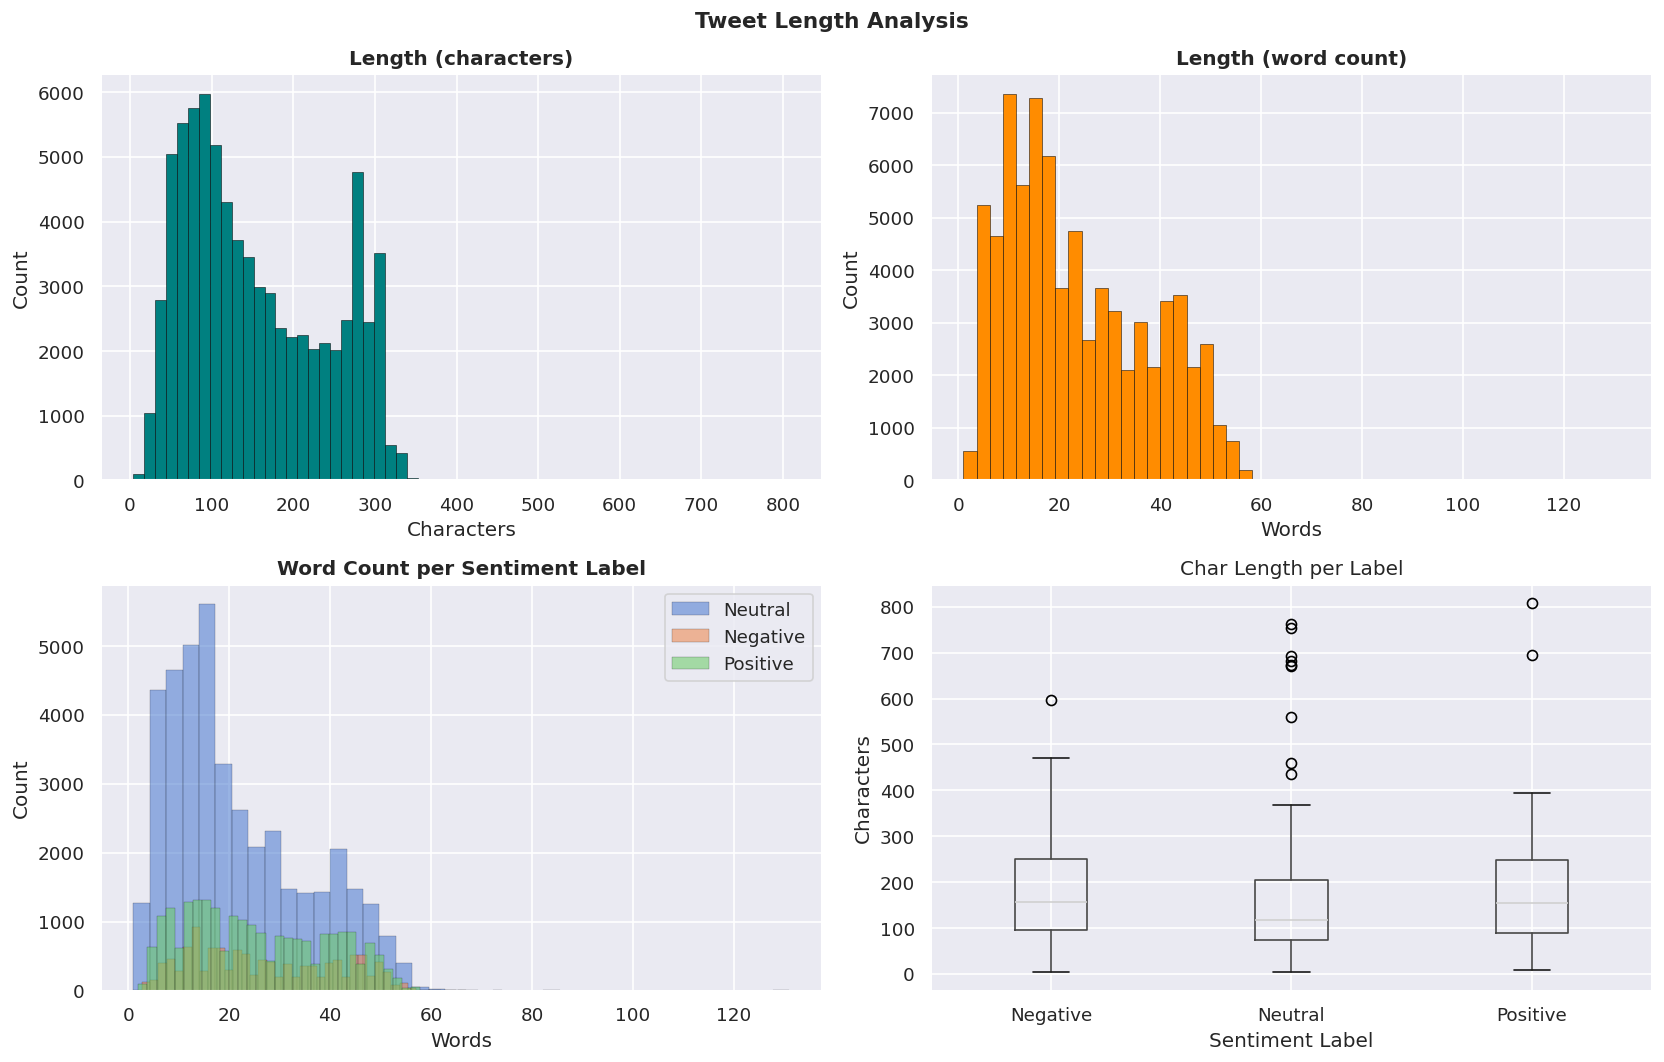

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0][0].hist(df['tweet_len_chars'], bins=60, color='teal', edgecolor='black', linewidth=0.3)
axes[0][0].set_title('Length (characters)', fontweight='bold')
axes[0][0].set_xlabel('Characters'); axes[0][0].set_ylabel('Count')

axes[0][1].hist(df['tweet_len_words'], bins=50, color='darkorange', edgecolor='black', linewidth=0.3)
axes[0][1].set_title('Length (word count)', fontweight='bold')
axes[0][1].set_xlabel('Words'); axes[0][1].set_ylabel('Count')

for label in df[LABEL_COL].unique():
    axes[1][0].hist(df[df[LABEL_COL]==label]['tweet_len_words'],
                   bins=40, alpha=0.55, label=str(label), edgecolor='black', linewidth=0.2)
axes[1][0].set_title('Word Count per Sentiment Label', fontweight='bold')
axes[1][0].set_xlabel('Words'); axes[1][0].set_ylabel('Count')
axes[1][0].legend()

df.boxplot(column='tweet_len_chars', by=LABEL_COL, ax=axes[1][1])
axes[1][1].set_title('Char Length per Label')
axes[1][1].set_xlabel('Sentiment Label'); axes[1][1].set_ylabel('Characters')
plt.sca(axes[1][1]); plt.title('Char Length per Label')

plt.suptitle('Tweet Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The maximum tweet length is 134 words, while the 75th percentile is valued at 34 words.


This indicates that at least three-quarters of the tweets are of moderate length, whereas only a small percentage are significantly longer.

----------------

In [23]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','it',
    'this','that','with','was','are','be','as','by','from','i','my','me','we',
    'you','he','she','they','have','has','had','do','did','not','no','so',
    'if','its','just','will','can','all','up','what','rt','amp','bitcoin','btc'
}

def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

df['tokens_eda'] = df[TEXT_COL].apply(simple_clean)
df[[TEXT_COL, 'tokens_eda']].head(3)

,text,tokens_eda
0,Most people underestimate the impact #Bitcoin ...,"[most, people, underestimate, impact, individu..."
1,#Bitcoin has started a new yearly candle https...,"[started, new, yearly, candle]"
2,@DESTROYBINARY did people forget that the amog...,"[people, forget, amogus, meme, edit, never, cr..."


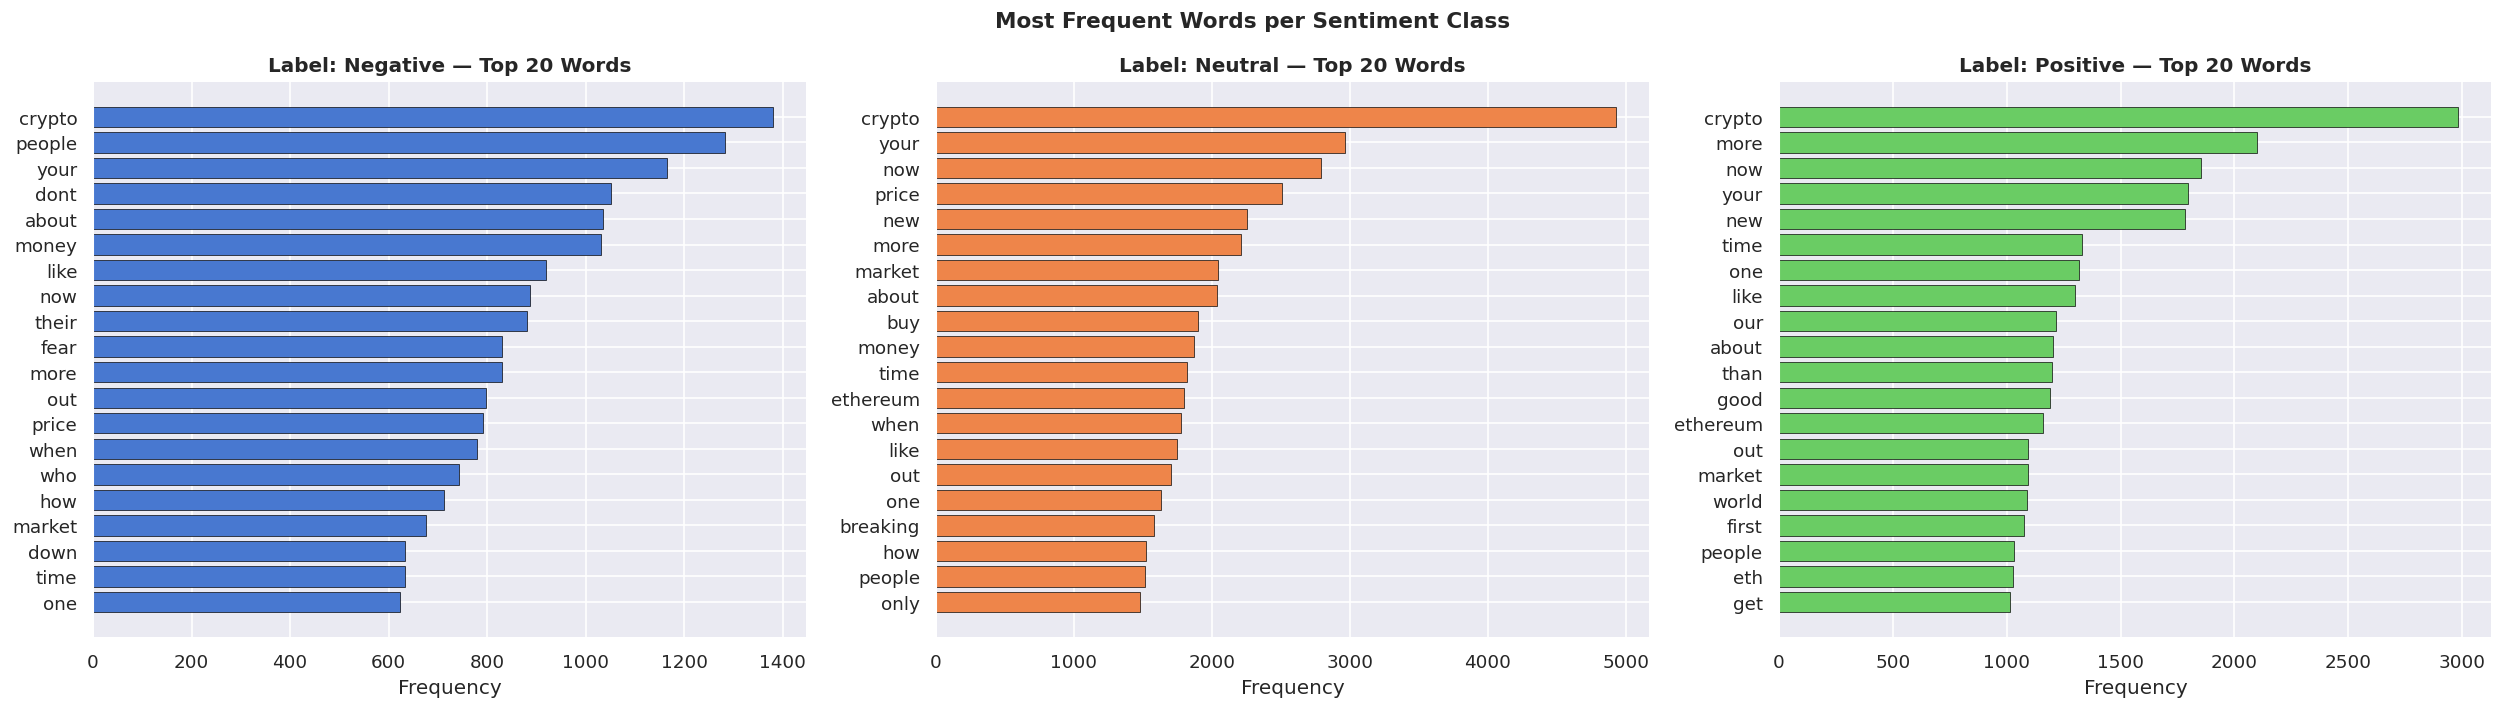

In [24]:
TOP_N = 20
fig, axes = plt.subplots(1, len(unique_labels), figsize=(7*len(unique_labels), 6))
if len(unique_labels) == 1:
    axes = [axes]

for ax, label in zip(axes, unique_labels):
    tokens_flat = [t for row in df[df[LABEL_COL]==label]['tokens_eda'] for t in row]
    top_words = Counter(tokens_flat).most_common(TOP_N)
    if top_words:
        words, counts = zip(*top_words)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=sns.color_palette('muted')[unique_labels.index(label)],
                edgecolor='black', linewidth=0.4)
    ax.set_title(f'Label: {label} — Top {TOP_N} Words', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Words such as dont or down frequently appear within the Negative label, whereas first, new, and good manifest within the Positive category.

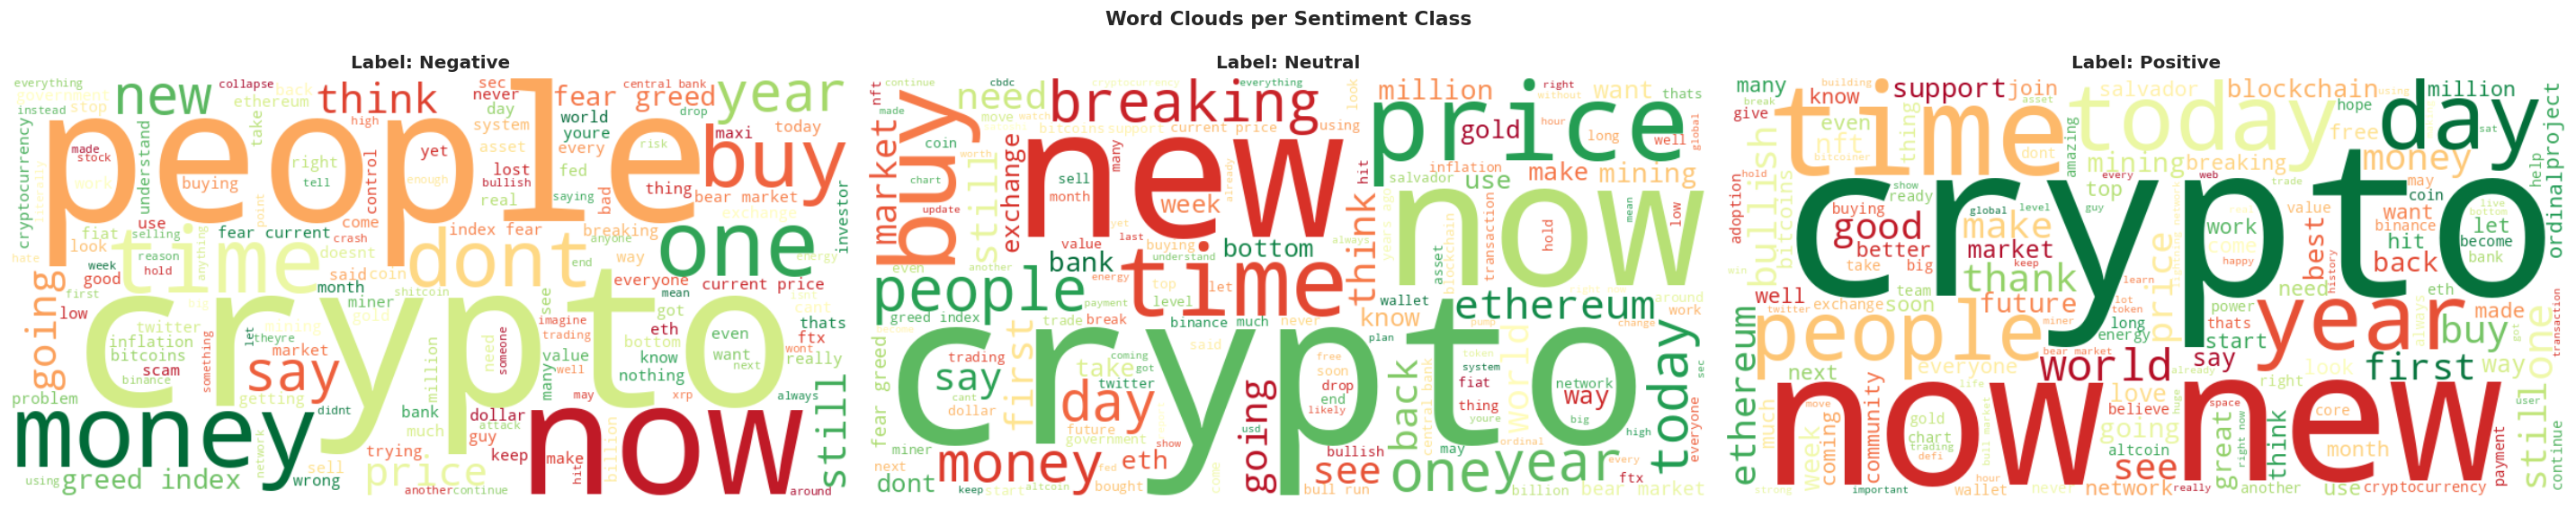

In [25]:
fig, axes = plt.subplots(1, len(unique_labels), figsize=(8*len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]
for ax, label in zip(axes, unique_labels):
    tokens_flat = [t for row in df[df[LABEL_COL]==label]['tokens_eda'] for t in row]
    wc = WordCloud(width=800, height=400, background_color='white',
            colormap='RdYlGn', max_words=150).generate(' '.join(tokens_flat))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Label: {label}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Word Clouds per Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

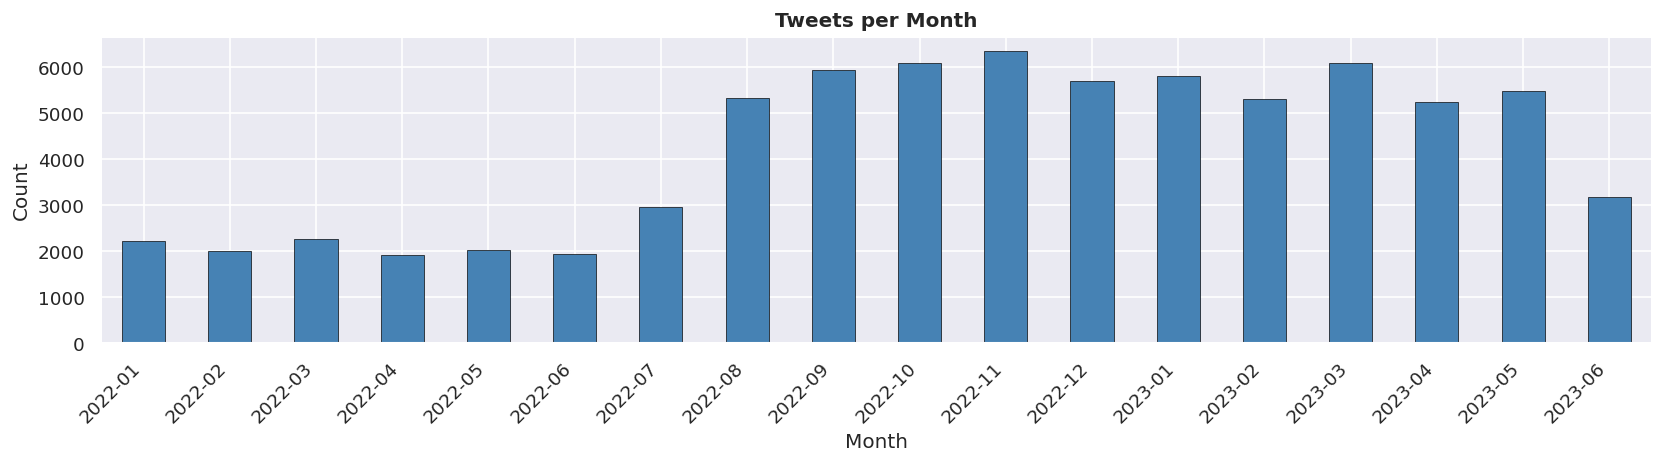

In [26]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M')
fig, ax = plt.subplots(figsize=(14, 4))
df.groupby('month').size().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Tweets per Month', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

It is evident that the number of tweets experienced a sharp increase in August 2022.


A trend regarding Bitcoin likely commenced at that time and persisted until June 2023.

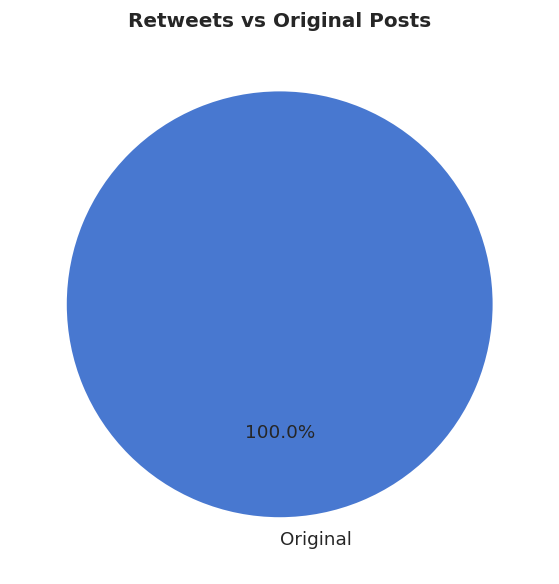

Retweets  : 0  (0.0%)
Originals : 75,955  (100.0%)


In [27]:
df['is_retweet'] = df[TEXT_COL].str.startswith('RT @')
rt_counts = df['is_retweet'].value_counts()
rt_labels = ['Retweet' if x else 'Original' for x in rt_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(rt_counts.values, labels=rt_labels, autopct='%1.1f%%',
       colors=sns.color_palette('muted', 2),
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
       startangle=90)
ax.set_title('Retweets vs Original Posts', fontweight='bold')
plt.tight_layout()
plt.show()

n_retweets  = df['is_retweet'].sum()
n_originals = (~df['is_retweet']).sum()
print(f"Retweets  : {n_retweets:,}  ({n_retweets/len(df)*100:.1f}%)")
print(f"Originals : {n_originals:,}  ({n_originals/len(df)*100:.1f}%)")

In [28]:
ENGAGEMENT_COLS = ['reply_count', 'like_count', 'retweet_count']
df['engagement_score'] = df[ENGAGEMENT_COLS].sum(axis=1)

print('=== TOP 5 Most Popular Tweets ===')
top5 = df.nlargest(5, 'engagement_score')[['text', 'sentiment_label', 'like_count', 'retweet_count', 'reply_count', 'engagement_score']]
pd.set_option('display.max_colwidth', 80)
print(top5.to_string(index=False))

print('\n=== TOP 5 Least Popular Tweets ===')
bot5 = df.nsmallest(5, 'engagement_score')[['text', 'sentiment_label', 'like_count', 'retweet_count', 'reply_count', 'engagement_score']]
print(bot5.to_string(index=False))

=== TOP 5 Most Popular Tweets ===
                                                                                                                                                                                                                                                                                                                                   text sentiment_label  like_count  retweet_count  reply_count  engagement_score
                                                                                                                                                                                                             Screaming and crying as a six year old trying to explain what bitcoin is to my parents mid-divorce https://t.co/CgaXZTuRHo        Negative      383127          39266         1208            423601
I FOUND THE EASTER EGG 🥚 \n\nI GUESS YOU GET SOMETHING AFTER ALL 🤑\n\nTHANK YOU ! @Pauly0x \n🔗 https://t.co/Xt67Evs3Nd\n\nTIP: You won't know If you've found it u

In [29]:
print(f"\nTweets with 0 quotes : {(df['quote_count']==0).sum():,}")
print(f"Tweets with 1+ quotes: {(df['quote_count']>0).sum():,}")
print(f"Max quote count      : {df['quote_count'].max():,}")
print(f"\n=== TOP 5 Most Quoted Tweets ===")
print(df.nlargest(5, 'quote_count')[['text', 'sentiment_label', 'quote_count']].to_string(index=False))


Tweets with 0 quotes : 12,021
Tweets with 1+ quotes: 63,934
Max quote count      : 45,401

=== TOP 5 Most Quoted Tweets ===
                                                                                                                                                                                                                                                                                                                text sentiment_label  quote_count
                                                                                                                                                                   Happy $50,000 in bitcoin. That’s what we’re giving away. Follow @cashapp and QRT with your $cashtag to enter. #CashAppDay https://t.co/bNUP326Lan        Positive        45401
                                                                                                                             It’s an extra special Cash App Friday because we’re giving away $10k in Bi

The dataset contains no retweets—specifically, tweets initiated in the format RE@...


There are tweets without likes, comments, or retweets; however, their textual content is significant for model training.


Furthermore, highly popular tweets are present within the dataset, as evidenced by both quantitative metrics and citations.

----------------------

# Text Preprocessing

In [30]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
negations = {'not', 'no', 'nor'}
STOPWORDS = STOPWORDS - negations

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


-----------------------------
## Preprocessing function:

In [31]:
def preprocess_tweet(text: str) -> str:
    text = unicodedata.normalize('NFKC', text)

    # 1. Lowercase
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 3. Remove @mentions ─
    text = re.sub(r'@\w+', '', text)

    # ── 4. Remove # but keep the word ─────────────────────────
    text = re.sub(r'#(\w+)', r'\1', text)

    # ── 5. Remove $ but keep the word ─────────────────────────
    text = re.sub(r'\$(\w+)', r'\1', text)

    # ── 6. Remove emojis & unicode symbols ────────────────────
    text = ''.join(
        c for c in text
        if unicodedata.category(c) not in ('So', 'Sm', 'Sk', 'Sc')
        and ord(c) < 0x10000
    )

    # ── 7. Remove newlines & tabs ─────────────────────────────
    text = re.sub(r'[\n\r\t]', ' ', text)

    # 8. Remove punctuation & special characters
    #    Keep: letters, digits, spaces
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # 9. Remove stopwords ─
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]

    # 10. Remove extra whitespace
    text = ' '.join(tokens).strip()

    return text

print('preprocess_tweet() defined.')

preprocess_tweet() defined.


### Example

In [32]:
test_cases = [
    "#BITCOIN BOUNCING BACK! 🚀",
    "@DestroyBinary Bitcoin is going to ZERO https://t.co/XcHlHVDzUU",
    "$BTC\n\nBitcoin has a 99.98% uptime\nHigher than Google!",
    "In 2022, #Bitcoin crashed from $45,000 to $20,000 😢",
    "If your coin has a CEO… it's not your coin. Buy #Bitcoin instead.",
    "\"I would love #bitcoin to go lower because I would buy more\" -- Jordan Belfort @wolfofwallst"
]

print('=== Preprocessing Sanity Check ===\n')
for tweet in test_cases:
    cleaned = preprocess_tweet(tweet)
    print(f'  ORIGINAL : {tweet}')
    print(f'  CLEANED  : {cleaned}')
    print()

=== Preprocessing Sanity Check ===

  ORIGINAL : #BITCOIN BOUNCING BACK! 🚀
  CLEANED  : bitcoin bouncing back

  ORIGINAL : @DestroyBinary Bitcoin is going to ZERO https://t.co/XcHlHVDzUU
  CLEANED  : bitcoin going zero

  ORIGINAL : $BTC

Bitcoin has a 99.98% uptime
Higher than Google!
  CLEANED  : btc bitcoin 9998 uptime higher google

  ORIGINAL : In 2022, #Bitcoin crashed from $45,000 to $20,000 😢
  CLEANED  : 2022 bitcoin crashed 45000 20000

  ORIGINAL : If your coin has a CEO… it's not your coin. Buy #Bitcoin instead.
  CLEANED  : coin ceo not coin buy bitcoin instead

  ORIGINAL : "I would love #bitcoin to go lower because I would buy more" -- Jordan Belfort @wolfofwallst
  CLEANED  : would love bitcoin go lower would buy jordan belfort



### Full dataset

In [33]:
print('Preprocessing tweets...')
df['text_clean'] = df[TEXT_COL].apply(preprocess_tweet)
print(f'Done! {len(df):,} tweets processed.')

# Quick preview
df[[TEXT_COL, 'text_clean']].head(5)

Preprocessing tweets...
Done! 75,955 tweets processed.


,text,text_clean
0,Most people underestimate the impact #Bitcoin will have on individual sovere...,people underestimate impact bitcoin individual sovereignty personal freedom
1,#Bitcoin has started a new yearly candle https://t.co/XcHlHVDzUU,bitcoin started new yearly candle
2,@DESTROYBINARY did people forget that the amogus meme was an edit of a 'bitc...,people forget amogus meme edit bitcoin never crash comic made
3,"In 2017, miners attempted to assert control over the #Bitcoin protocol, and ...",2017 miners attempted assert control bitcoin protocol failed thanks bip148 u...
4,Yearly Close \nMonthly Close\nDaily Close\n\nhave all just taken place\n\nHa...,yearly close monthly close daily close taken place happy new year bitcoin im...


Proper nouns, such as Jordan Belfort, are redundant for text processing; however, removing proper nouns could inadvertently eliminate the term Bitcoin, which is central to the dataset.

### Proper nouns

In [34]:
def preprocess_tweet_keep_case(text: str) -> str:
    # Same as preprocess_tweet but skip the lowercase step
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\$(\w+)', r'\1', text)
    text = re.sub(r'[\n\r\t]', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # keep uppercase
    text = ' '.join(text.split()).strip()
    return text

df['text_cased'] = df['text'].apply(preprocess_tweet_keep_case)

In [35]:

proper_nouns = []
for tweet in df['text_cased']:
    tokens = word_tokenize(tweet)
    tagged = pos_tag(tokens)
    proper_nouns.extend([word for word, tag in tagged if tag == 'NNP'])

# Count and display
proper_noun_counts = Counter(proper_nouns)
print(f'Unique proper nouns found: {len(proper_noun_counts)}')
print('\nTop 50 most frequent:')
for word, count in proper_noun_counts.most_common(50):
    print(f'  {word:<20} {count:,}')


Unique proper nouns found: 26226

Top 50 most frequent:
  Bitcoin              54,368
  BTC                  8,433
  Crypto               3,027
  BITCOIN              2,798
  IN                   2,715
  Ethereum             2,551
  ETH                  2,206
  US                   2,053
  Im                   1,806
  Fear                 1,492
  El                   1,334
  BREAKING             1,330
  Binance              1,250
  A                    1,242
  Greed                1,141
  Salvador             1,140
  FTX                  1,067
  Index                991
  BNB                  991
  Current              938
  NFT                  916
  NEW                  856
  SEC                  845
  Dont                 824
  Satoshi              819
  CEO                  803
  Twitter              777
  Bank                 766
  Bitcoins             736
  NFTs                 729
  XRP                  691
  New                  690
  Buy                  629
  TO              

As the volume of proper nouns is excessive, the proposal to exclude specific nouns will be omitted.

### Post-Processing Quality Check

### Empty tweets

In [36]:
empty_mask = df['text_clean'].str.strip() == ''
print(f'Tweets that became empty after cleaning: {empty_mask.sum()}')

if empty_mask.sum() > 0:
    print('\nExamples of tweets that became empty:')
    print(df[empty_mask][TEXT_COL].head(10).to_string())

    df = df[~empty_mask].reset_index(drop=True)
    print(f'\nDropped. Remaining rows: {len(df):,}')

Tweets that became empty after cleaning: 10

Examples of tweets that became empty:
17306                   How we do? https://t.co/a9QFJZYFe0
17373    @BigBluexlt @brixwe More. https://t.co/SK4Wzdk5xL
28775                  We are here https://t.co/ibMcrSJ21y
32748             who? who? who? 👀 https://t.co/aFtHhhbsIF
38544                     @elonmusk @stillgray For the 💍 😂
39427                      More:👇\nhttps://t.co/Ec7RHJoTK6
57368                    It's over https://t.co/Uz7gLDZq3I
59575                      More 👇\nhttps://t.co/SIMerXcoay
60932                       This 👇 https://t.co/cWo5HGN3ao
70631                 Where is it? https://t.co/zT7rkPmV3G

Dropped. Remaining rows: 75,945


### Short tweets

In [37]:
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

print('=== Cleaned Tweet Length Statistics ===')
print(df['clean_word_count'].describe().round(2))

print(f'\nTweets with only 1 word : {(df["clean_word_count"] == 1).sum()}')
print(f'Tweets with only 2 words: {(df["clean_word_count"] == 2).sum()}')

# Show the 1-word tweets
one_word = df[df['clean_word_count'] == 1]
if len(one_word) > 0:
    print(f'\n=== 1-word tweets (showing up to 10) ===')
    print(one_word[[TEXT_COL, 'text_clean', LABEL_COL]].head(10).to_string())

=== Cleaned Tweet Length Statistics ===
count    75945.00
mean        13.79
std          8.35
min          1.00
25%          7.00
50%         12.00
75%         20.00
max         51.00
Name: clean_word_count, dtype: float64

Tweets with only 1 word : 244
Tweets with only 2 words: 1772

=== 1-word tweets (showing up to 10) ===
                                                        text text_clean sentiment_label
1303                                              Or Bitcoin    bitcoin         Neutral
2089                         Bitcoin https://t.co/3NqEoJSCiX    bitcoin         Neutral
3090                 Why we #Bitcoin https://t.co/zEbHIDkfvR    bitcoin         Neutral
3379                   #Bitcoin only https://t.co/AYTykyjm9Y    bitcoin         Neutral
3884   #BITCOIN: ALL IN!!!!!!!!!!!!! https://t.co/HLOjmkRs2Z    bitcoin        Positive
4301                                              Bitcoin 🇺🇸    bitcoin        Positive
5228                                               Bitcoi

The mean and maximum word counts in the tweets have been halved, which directly affects the maximum sequence length required for subsequent vectorization.


It is observed that there are 244 tweets consisting of only a single word, the majority of which likely contain only the term bitcoin.


Such tweets provide no utility for the model and contain no information correlated with the label.

In [38]:
before = len(df)
df = df[df['clean_word_count'] > 1].reset_index(drop=True)
print(f'Dropped {before - len(df)} one-word tweets.')
print(f'Remaining rows: {len(df):,}')

Dropped 244 one-word tweets.
Remaining rows: 75,701


In [39]:
MAX_SEQ_LEN = int(np.percentile(df['clean_word_count'], 95))
print(f'95th percentile word count (cleaned): {MAX_SEQ_LEN}')
print(f'This will be our MAX_SEQ_LEN for padding/truncation in Embedding.')

coverage = (df['clean_word_count'] <= MAX_SEQ_LEN).mean() * 100
print(f'Tweets covered at MAX_SEQ_LEN={MAX_SEQ_LEN}: {coverage:.1f}%')

95th percentile word count (cleaned): 29
This will be our MAX_SEQ_LEN for padding/truncation in Embedding.
Tweets covered at MAX_SEQ_LEN=29: 96.0%


### Lable Encoding

In [40]:
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id_to_label = {v: k for k, v in label_map.items()}

df['label_encoded'] = df[LABEL_COL].map(label_map)

print('Label mapping:')
for k, v in label_map.items():
    print(f'  {k} → {v}')

print(f'\nAny nulls in encoded labels: {df["label_encoded"].isnull().sum()}')
print(f'\nEncoded label distribution:')
print(df['label_encoded'].value_counts().sort_index())

Label mapping:
  Negative → 0
  Neutral → 1
  Positive → 2

Any nulls in encoded labels: 0

Encoded label distribution:
label_encoded
0    11842
1    41379
2    22480
Name: count, dtype: int64


### DataFrames Split

In [41]:
df_classification = df[['text_clean', 'label_encoded']].copy()
df_classification.columns = ['text', 'label']

df_regression = df[['text_clean', SCORE_COL]].copy()
df_regression.columns = ['text', 'score']

print(f'Classification df : {df_classification.shape}')
print(df_classification.head(3))

print(f'\nRegression df     : {df_regression.shape}')
print(df_regression.head(3))

Classification df : (75701, 2)
                                                                          text  \
0  people underestimate impact bitcoin individual sovereignty personal freedom   
1                                            bitcoin started new yearly candle   
2                people forget amogus meme edit bitcoin never crash comic made   

   label  
0      1  
1      1  
2      1  

Regression df     : (75701, 2)
                                                                          text  \
0  people underestimate impact bitcoin individual sovereignty personal freedom   
1                                            bitcoin started new yearly candle   
2                people forget amogus meme edit bitcoin never crash comic made   

      score  
0  0.717482  
1  0.810814  
2  0.606978  


---------------------

# Tokenization, Vocabulary Building & Splitting

### Train/Validation/Test split

In [42]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader


RANDOM_SEED = 18
VAL_SIZE    = 0.15
TEST_SIZE   = 0.15

def split_dataframe(df, val_size, test_size, seed, stratify_col=None):
    stratify = df[stratify_col] if stratify_col else None

    df_train_val, df_test = train_test_split(
        df, test_size=test_size, random_state=seed,
        shuffle=True, stratify=stratify
    )

    stratify_train_val = df_train_val[stratify_col] if stratify_col else None
    adjusted_val = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_train_val, test_size=adjusted_val, random_state=seed,
        shuffle=True, stratify=stratify_train_val
    )
    return df_train, df_val, df_test

train_cls, val_cls, test_cls = split_dataframe(df_classification, VAL_SIZE, TEST_SIZE, RANDOM_SEED, stratify_col='label')
train_reg, val_reg, test_reg = split_dataframe(df_regression, VAL_SIZE, TEST_SIZE, RANDOM_SEED)

print('=== Classification Split ===')
print(f'  Train : {len(train_cls):,}')
print(f'  Val   : {len(val_cls):,}')
print(f'  Test  : {len(test_cls):,}')
print(f'  Total : {len(train_cls) + len(val_cls) + len(test_cls):,}')

print('\n=== Regression Split ===')
print(f'  Train : {len(train_reg):,}')
print(f'  Val   : {len(val_reg):,}')
print(f'  Test  : {len(test_reg):,}')
print(f'  Total : {len(train_reg) + len(val_reg) + len(test_reg):,}')

# Verify label distribution is preserved across splits (stratification check)
print('\n=== Label Distribution in Splits (%) ===')
for name, split in [('Train', train_cls), ('Val', val_cls), ('Test', test_cls)]:
    dist = split['label'].value_counts(normalize=True) * 100
    print(f'  {name}: { {k: round(v,1) for k,v in dist.items()} }')


=== Classification Split ===
  Train : 52,990
  Val   : 11,355
  Test  : 11,356
  Total : 75,701

=== Regression Split ===
  Train : 52,990
  Val   : 11,355
  Test  : 11,356
  Total : 75,701

=== Label Distribution in Splits (%) ===
  Train: {1: 54.7, 2: 29.7, 0: 15.6}
  Val: {1: 54.7, 2: 29.7, 0: 15.6}
  Test: {1: 54.7, 2: 29.7, 0: 15.6}


----------------

In [43]:
MIN_FREQ = 2

word_counts = Counter(
    word
    for tweet in train_cls['text']
    for word in tweet.split()
)

print(f'Unique words in training set        : {len(word_counts):,}')
print(f'Words with freq >= {MIN_FREQ}               : {sum(1 for c in word_counts.values() if c >= MIN_FREQ):,}')
print(f'Words with freq == 1 (hapax)        : {sum(1 for c in word_counts.values() if c == 1):,}')

Unique words in training set        : 41,687
Words with freq >= 2               : 20,737
Words with freq == 1 (hapax)        : 20,950


### Index mapping

In [44]:
PAD_IDX = 0
UNK_IDX = 1

vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}

for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f'Vocabulary size (including <PAD> and <UNK>): {VOCAB_SIZE:,}')

# Reverse mapping: index → word (useful for debugging later)
idx_to_word = {idx: word for word, idx in vocab.items()}

Vocabulary size (including <PAD> and <UNK>): 20,739


### Text to int

In [45]:
def tokenize(text: str, vocab: dict, unk_idx: int) -> list:
    return [vocab.get(word, unk_idx) for word in text.split()]

# Test it
sample = train_cls['text'].iloc[0]
print(f'Text    : {sample}')
print(f'Indices : {tokenize(sample, vocab, UNK_IDX)}')

Text    : waiting basically free web3 cryptocurency bullish bullrun bitcoin blockchain crypto ethereum bnb playtoearn cryptogaming
Indices : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1]


In [46]:
def unk_rate(df, vocab, unk_idx):
    total_tokens = 0
    unk_tokens   = 0
    for tweet in df['text']:
        indices = tokenize(tweet, vocab, unk_idx)
        total_tokens += len(indices)
        unk_tokens   += indices.count(unk_idx)
    return unk_tokens / total_tokens * 100

unk_val  = unk_rate(val_cls,  vocab, UNK_IDX)
unk_test = unk_rate(test_cls, vocab, UNK_IDX)

print(f'<UNK> rate — Val  set: {unk_val:.2f}%')
print(f'<UNK> rate — Test set: {unk_test:.2f}%')

<UNK> rate — Val  set: 4.52%
<UNK> rate — Test set: 4.31%


It is evident that the majority of words in both the training and validation sets are recognized by the vocabulary.

### Padding and Truncation

In [47]:
def pad_or_truncate(indices: list, max_len: int, pad_idx: int) -> list:

    if len(indices) < max_len:
        return [pad_idx] * (max_len - len(indices)) + indices
    else:
        return indices[-max_len:]

sample_indices = tokenize(sample, vocab, UNK_IDX)
padded = pad_or_truncate(sample_indices, MAX_SEQ_LEN, PAD_IDX)
print(f'Original length : {len(sample_indices)}')
print(f'Padded sequence : {padded}')
print(f'Padded length   : {len(padded)}')

Original length : 14
Padded sequence : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1]
Padded length   : 29


### Dataset + DataLoader

In [48]:
class TweetDataset(Dataset):
    def __init__(self, df, vocab, max_len, pad_idx, unk_idx, task='classification'):
        """
        Args:
            df      : dataframe with 'text' and either 'label' or 'score' column
            vocab   : word → index dictionary
            max_len : MAX_SEQ_LEN
            pad_idx : index for <PAD>
            unk_idx : index for <UNK>
            task    : 'classification' or 'regression'
        """
        self.task    = task
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.vocab   = vocab

        self.sequences = [
            pad_or_truncate(tokenize(text, vocab, unk_idx), max_len, pad_idx)
            for text in df['text']
        ]

        if task == 'classification':
            self.targets = df['label'].tolist()
        else:
            self.targets = df['score'].tolist()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)

        if self.task == 'classification':
            y = torch.tensor(self.targets[idx], dtype=torch.long)
        else:
            y = torch.tensor(self.targets[idx], dtype=torch.float)

        return x, y

print('TweetDataset class defined.')

TweetDataset class defined.


In [49]:
BATCH_SIZE = 64

# Classification datasets
train_cls_dataset = TweetDataset(train_cls, vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='classification')
val_cls_dataset   = TweetDataset(val_cls,   vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='classification')
test_cls_dataset  = TweetDataset(test_cls,  vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='classification')

# Regression datasets
train_reg_dataset = TweetDataset(train_reg, vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='regression')
val_reg_dataset   = TweetDataset(val_reg,   vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='regression')
test_reg_dataset  = TweetDataset(test_reg,  vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, task='regression')

# DataLoaders
train_cls_loader = DataLoader(train_cls_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_cls_loader   = DataLoader(val_cls_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_cls_loader  = DataLoader(test_cls_dataset,  batch_size=BATCH_SIZE, shuffle=False)

train_reg_loader = DataLoader(train_reg_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_reg_loader   = DataLoader(val_reg_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_reg_loader  = DataLoader(test_reg_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('=== Datasets & DataLoaders created ===')
print(f'  Classification — Train: {len(train_cls_dataset):,} | Val: {len(val_cls_dataset):,} | Test: {len(test_cls_dataset):,}')
print(f'  Regression     — Train: {len(train_reg_dataset):,} | Val: {len(val_reg_dataset):,} | Test: {len(test_reg_dataset):,}')
print(f'  Batch size: {BATCH_SIZE}')

=== Datasets & DataLoaders created ===
  Classification — Train: 52,990 | Val: 11,355 | Test: 11,356
  Regression     — Train: 52,990 | Val: 11,355 | Test: 11,356
  Batch size: 64


In [50]:
x_batch, y_batch = next(iter(train_cls_loader))

print('=== Single Batch Inspection (Classification) ===')
print(f'  x shape : {x_batch.shape}')
print(f'  y shape : {y_batch.shape} ')
print(f'  x dtype : {x_batch.dtype}')
print(f'  y dtype : {y_batch.dtype}')
print(f'\n  First sequence in batch:')
print(f'  Indices : {x_batch[0].tolist()}')
print(f'  Words   : {[idx_to_word[i.item()] for i in x_batch[0]]}')
print(f'  Label   : {y_batch[0].item()} ({id_to_label[y_batch[0].item()]})')

=== Single Batch Inspection (Classification) ===
  x shape : torch.Size([64, 29])
  y shape : torch.Size([64]) 
  x dtype : torch.int64
  y dtype : torch.int64

  First sequence in batch:
  Indices : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 319, 320, 321, 9431, 319, 324, 247, 1]
  Words   : ['<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 'bitcoin', 'fear', 'greed', 'index', '34', 'fear', 'current', 'price', '<UNK>']
  Label   : 0 (Negative)


### Add GloVe

In [51]:
import os
import urllib.request
import zipfile

# GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.twitter.27B.zip'
# GLOVE_ZIP  = 'glove.twitter.27B.zip'
GLOVE_FILE = 'glove.twitter.27B.100d.txt'
EMBED_DIM  = 100

if not os.path.exists(GLOVE_FILE):
    print('Downloading GloVe Twitter embeddings (~1.4GB)...')
    print('This may take a few minutes on Colab GPU...')
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    print('Extracting...')
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract(GLOVE_FILE)
    os.remove(GLOVE_ZIP)
    print('Done!')
else:
    print(f'{GLOVE_FILE} already exists, skipping download.')

glove.twitter.27B.100d.txt already exists, skipping download.


In [52]:
print('Loading GloVe vectors...')
glove_vectors = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec

print(f'GloVe vocabulary size : {len(glove_vectors):,}')
print(f'Embedding dimension   : {EMBED_DIM}')

Loading GloVe vectors...
GloVe vocabulary size : 388,946
Embedding dimension   : 100


In [53]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)

matched    = 0
unmatched  = 0

for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        matched += 1
    else:
        embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, EMBED_DIM)
        unmatched += 1

embedding_matrix[PAD_IDX] = np.zeros(EMBED_DIM)

coverage = matched / VOCAB_SIZE * 100
print(f'Vocabulary coverage:')
print(f'  Matched in GloVe   : {matched:,}  ({coverage:.1f}%)')
print(f'  Not in GloVe       : {unmatched:,}  ({100-coverage:.1f}%)')
print(f'  Embedding matrix shape: {embedding_matrix.shape}')

Vocabulary coverage:
  Matched in GloVe   : 14,277  (68.8%)
  Not in GloVe       : 6,462  (31.2%)
  Embedding matrix shape: (20739, 100)


In [54]:
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float)
print(f'Embedding tensor shape: {embedding_tensor.shape}')
print('Pretrained embeddings ready!')

Embedding tensor shape: torch.Size([20739, 100])
Pretrained embeddings ready!


## Attention

In [55]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states):
        """
        Args:
            hidden_states: (batch, seq_len, hidden_dim)
        Returns:
            context: (batch, hidden_dim) — weighted sum
            weights: (batch, seq_len)    — attention weights
        """
        scores = self.attention(hidden_states)

        weights = torch.softmax(scores, dim=1)

        context = (weights * hidden_states).sum(dim=1)

        return context, weights.squeeze(2)

print('Attention class defined.')

Attention class defined.


# Model Building (LSTM, GRU, CNN)

In [56]:
EMBED_DIM    = 100
HIDDEN_DIM   = 128
NUM_LAYERS   = 2
DROPOUT      = 0.0
NUM_FILTERS  = 128
KERNEL_SIZES = [2, 3, 4]
NUM_CLASSES  = 3

## LSTM

In [57]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 dropout, pad_idx, num_classes, task='classification'):
        super(LSTMModel, self).__init__()

        self.task       = task
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding.from_pretrained(
            embeddings  = embedding_tensor,
            freeze      = False,
            padding_idx = pad_idx
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Attention
        self.attention = Attention(hidden_dim * 2)

        self.dropout = nn.Dropout(dropout)
        # Fully connected output layer
        if task == 'classification':
            self.fc = nn.Linear(hidden_dim*2, num_classes)
        else:
            self.fc = nn.Linear(hidden_dim*2, 1)

    def forward(self, x):

        # Embedding
        embedded = self.embedding(x)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)

        context, weights = self.attention(lstm_out)

        #last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)

        # Dropout
        out = self.dropout(context)

        # Fully Connected
        out = self.fc(out)

        if self.task == 'regression':
            out = out.squeeze(1)

        return out

print('LSTMModel defined.')

LSTMModel defined.


## GRU

In [58]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 dropout, pad_idx, num_classes, task='classification'):
        super(GRUModel, self).__init__()

        self.task       = task
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding.from_pretrained(
            embeddings  = embedding_tensor,
            freeze      = False,
            padding_idx = pad_idx
        )

        # GRU layer (no cell state)
        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        # Attention
        self.attention = Attention(hidden_dim * 2)

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        if task == 'classification':
            self.fc = nn.Linear(hidden_dim*2, num_classes)
        else:
            self.fc = nn.Linear(hidden_dim*2, 1)

    def forward(self, x):

        # Embedding
        embedded = self.embedding(x)

        # GRU
        gru_out, hidden = self.gru(embedded)

        context, weights = self.attention(gru_out)


        #last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)

        # Dropout
        out = self.dropout(context)

        # Fully Connected
        out = self.fc(out)

        if self.task == 'regression':
            out = out.squeeze(1)

        return out

print('GRUModel defined.')

GRUModel defined.


## CNN

In [59]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_sizes,
                 dropout, pad_idx, num_classes, task='classification'):
        super(CNNModel, self).__init__()

        self.task = task

        # Embedding layer
        self.embedding = nn.Embedding.from_pretrained(
            embeddings  = embedding_tensor,
            freeze      = False,
            padding_idx = pad_idx
        )

        # Convolutional layers (one per kernel size)
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels  = embed_dim,
                out_channels = num_filters,
                kernel_size  = k
            )
            for k in kernel_sizes
        ])

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        if task == 'classification':
            self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)
        else:
            self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        embedded = embedded.permute(0, 2, 1)

        # Convolution + ReLU + Max Pooling
        pooled_outputs = []
        for conv in self.convs:
            conv_out = torch.relu(conv(embedded))

            pooled = torch.max(conv_out, dim=2).values

            pooled_outputs.append(pooled)

        cat = torch.cat(pooled_outputs, dim=1)

        # Dropout
        out = self.dropout(cat)

        # Fully Connected
        out = self.fc(out)

        if self.task == 'regression':
            out = out.squeeze(1)

        return out

print('CNNModel defined.')

CNNModel defined.


## Instantion of the models

### Classification

In [60]:
lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

### Regression

In [63]:
lstm_reg = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

gru_reg  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

cnn_reg  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='regression')

---------------

In [64]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== Trainable Parameters ===')
print(f'  LSTM Classification : {count_parameters(lstm_cls):,}')
print(f'  LSTM Regression     : {count_parameters(lstm_reg):,}')
print(f'  GRU  Classification : {count_parameters(gru_cls):,}')
print(f'  GRU  Regression     : {count_parameters(gru_reg):,}')
print(f'  CNN  Classification : {count_parameters(cnn_cls):,}')
print(f'  CNN  Regression     : {count_parameters(cnn_reg):,}')

=== Trainable Parameters ===
  LSTM Classification : 2,705,712
  LSTM Regression     : 2,705,198
  GRU  Classification : 2,548,016
  GRU  Regression     : 2,547,502
  CNN  Classification : 2,190,639
  CNN  Regression     : 2,189,869


---------------------

In [65]:
x_batch, y_batch = next(iter(train_cls_loader))

print('=== Forward Pass Sanity Check ===')
print(f'Input shape: {x_batch.shape}')

with torch.no_grad():
    out_lstm = lstm_cls(x_batch)
    out_gru  = gru_cls(x_batch)
    out_cnn  = cnn_cls(x_batch)

print(f'\nLSTM output shape : {out_lstm.shape}  (expected: [64, 3])')
print(f'GRU  output shape : {out_gru.shape}  (expected: [64, 3])')
print(f'CNN  output shape : {out_cnn.shape}  (expected: [64, 3])')

print(f'\nLSTM first sample output : {out_lstm[0].tolist()}')
print(f'GRU  first sample output : {out_gru[0].tolist()}')
print(f'CNN  first sample output : {out_cnn[0].tolist()}')

=== Forward Pass Sanity Check ===
Input shape: torch.Size([64, 29])

LSTM output shape : torch.Size([64, 3])  (expected: [64, 3])
GRU  output shape : torch.Size([64, 3])  (expected: [64, 3])
CNN  output shape : torch.Size([64, 3])  (expected: [64, 3])

LSTM first sample output : [0.05663049966096878, -0.019522709771990776, -0.06720010936260223]
GRU  first sample output : [0.008509334176778793, 0.10737685114145279, 0.09597031027078629]
CNN  first sample output : [-0.24451740086078644, -0.022361811250448227, -0.22470535337924957]


---------------------------------

# Training

In [66]:
from sklearn.metrics import f1_score, accuracy_score
import time

# Training Configuration
LEARNING_RATE = 0.001
NUM_EPOCHS    = 10
VAL_CHECKS    = 3

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Loss Functions

In [67]:
train_labels_array = np.array(train_cls['label'].tolist())
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_labels_array
)

print('Class weights:')
print(f'  Negative (0): {class_weights[0]:.4f}')
print(f'  Neutral  (1): {class_weights[1]:.4f}')
print(f'  Positive (2): {class_weights[2]:.4f}')

weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
classification_criterion = nn.CrossEntropyLoss(weight=weights_tensor)
regression_criterion     = nn.MSELoss()

print('\nLoss functions defined:')
print('  Classification → Weighted CrossEntropyLoss')
print('  Regression     → MSELoss')

Class weights:
  Negative (0): 2.1309
  Neutral  (1): 0.6098
  Positive (2): 1.1225

Loss functions defined:
  Classification → Weighted CrossEntropyLoss
  Regression     → MSELoss


### Training and Validation

In [68]:
def train_one_epoch(model, loader, optimizer, criterion, device, task):

    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        optimizer.zero_grad()
        predictions = model(x_batch)

        # Loss calculation
        loss = criterion(predictions, y_batch)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion, device, task):

    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)
            loss        = criterion(predictions, y_batch)
            total_loss += loss.item()

            if task == 'classification':
                preds = torch.argmax(predictions, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
            else:
                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)

    if task == 'classification':
        accuracy = accuracy_score(all_labels, all_preds)
        f1       = f1_score(all_labels, all_preds, average='weighted')
        return avg_loss, accuracy, f1
    else:
        mae = np.mean(np.abs(np.array(all_preds) - np.array(all_labels)))
        return avg_loss, mae

print('train_one_epoch() and evaluate() defined.')

train_one_epoch() and evaluate() defined.


### Training

In [69]:
def train_model(model, train_loader, val_loader, task,
                num_epochs, learning_rate, val_checks, device):

    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Loss function
    criterion = classification_criterion if task == 'classification' else regression_criterion

    # Tracking
    history = {
        'train_loss' : [],
        'val_loss'   : [],
        'val_metric1': [],
        'val_metric2': [],
    }

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    print(f'\n{"="*60}')
    print(f'  Task: {task.upper()}')
    print(f'  Model: {model.__class__.__name__}')
    print(f'  Device: {device}')
    print(f'{"="*60}')

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        # Training phase
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device, task
        )

        # Validation phase
        if task == 'classification':
            val_loss, val_acc, val_f1 = evaluate(
                model, val_loader, criterion, device, task
            )
            history['val_metric1'].append(val_acc)
            history['val_metric2'].append(val_f1)
            metric_str = f'Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}'
        else:
            val_loss, val_mae = evaluate(
                model, val_loader, criterion, device, task
            )
            history['val_metric1'].append(val_mae)
            metric_str = f'Val MAE: {val_mae:.4f}'

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        elapsed = time.time() - start_time

        print(f'Epoch {epoch:02d}/{num_epochs} | '
              f'Time: {elapsed:.1f}s | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'{metric_str}')

        # Early stopping & best model saving
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            print(f'           Val loss improved → best model saved')
        else:
            patience_count += 1
            print(f'             No improvement ({patience_count}/{val_checks})')
            if patience_count >= val_checks:
                print(f'\n Early stopping triggered at epoch {epoch}')
                break

    print(f'\nBest val loss: {best_val_loss:.4f}')
    print(f'{"="*60}\n')

    return history, best_state

print('train_model() defined.')

train_model() defined.


In [70]:
lstm_cls = lstm_cls.to(device)
gru_cls  = gru_cls.to(device)
cnn_cls  = cnn_cls.to(device)


--------------

## Optuna hyperparameter search

In [80]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'Optuna version: {optuna.__version__}')

Optuna version: 4.8.0


In [81]:
def objective(trial):
    hidden_dim  = trial.suggest_categorical('hidden_dim',  [64, 128, 256])
    num_layers  = trial.suggest_categorical('num_layers',  [1, 2])
    dropout     = trial.suggest_categorical('dropout',     [0.3, 0.5, 0.7])
    lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = GRUModel(
        vocab_size  = VOCAB_SIZE,
        embed_dim   = EMBED_DIM,
        hidden_dim  = hidden_dim,
        num_layers  = num_layers,
        dropout     = dropout,
        pad_idx     = PAD_IDX,
        num_classes = NUM_CLASSES,
        task        = 'classification'
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_val_loss  = float('inf')
    patience_count = 0
    TRIAL_EPOCHS   = 5
    TRIAL_PATIENCE = 2

    for epoch in range(TRIAL_EPOCHS):
        model.train()
        for x_batch, y_batch in train_cls_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            predictions = model(x_batch)
            loss = classification_criterion(predictions, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_cls_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                predictions = model(x_batch)
                loss = classification_criterion(predictions, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_cls_loader)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= TRIAL_PATIENCE:
                break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_loss

print('objective() defined.')

objective() defined.


In [82]:

# N_TRIALS = 15

# print(f'Starting Optuna search with {N_TRIALS} trials...')
# print(f'Searching over:')
# print(f'  hidden_dim  : [64, 128, 256]')
# print(f'  num_layers  : [1, 2]')
# print(f'  dropout     : [0.3, 0.5, 0.7]')
# print(f'  lr          : [0.0001, 0.01] (log scale)')
# print()

# sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
# pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)

# study = optuna.create_study(
#     direction = 'minimize',
#     sampler   = sampler,
#     pruner    = pruner
# )

# study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# print('\nSearch complete!')
# print(f'  Total trials    : {len(study.trials)}')
# print(f'  Best val loss   : {study.best_value:.4f}')
# print(f'  Best params     : {study.best_params}')

Last time obtained results:

In [4]:
print(f"""Starting Optuna search with 15 trials...
Searching over:
  hidden_dim  : [64, 128, 256]
  num_layers  : [1, 2]
  dropout     : [0.3, 0.5, 0.7]
  lr          : [0.0001, 0.01] (log scale)


Best trial: 11. Best value: 0.627628: 100% 15/15 [04:48<00:00, 13.15s/it]
Search complete!
  Total trials    : 15
  Best val loss   : 0.6276
  Best params     : hidden_dim: 128, num_layers: 1, dropout: 0.7, lr: 0.0019742021520455684
""")

Starting Optuna search with 15 trials...
Searching over:
  hidden_dim  : [64, 128, 256]
  num_layers  : [1, 2]
  dropout     : [0.3, 0.5, 0.7]
  lr          : [0.0001, 0.01] (log scale)


Best trial: 11. Best value: 0.627628: 100% 15/15 [04:48<00:00, 13.15s/it]
Search complete!
  Total trials    : 15
  Best val loss   : 0.6276
  Best params     : hidden_dim: 128, num_layers: 1, dropout: 0.7, lr: 0.0019742021520455684



In [83]:
# print('=' * 55)
# print('  OPTUNA SEARCH RESULTS')
# print('=' * 55)
# print(f'\n  Best hyperparameters found:')
# for param, value in study.best_params.items():
#     print(f'    {param:<15} : {value}')
# print(f'\n  Best val loss: {study.best_value:.4f}')

# print(f'\n  Top 5 trials:')
# print(f'  {"Rank":<6} {"Val Loss":<12} {"hidden_dim":<12} '
#       f'{"num_layers":<12} {"dropout":<10} {"lr"}')
# print(f'  {"-"*65}')

# sorted_trials = sorted(study.trials,
#                        key=lambda t: t.value if t.value else float('inf'))
# for i, trial in enumerate(sorted_trials[:5]):
#     if trial.value:
#         print(f'  {i+1:<6} {trial.value:<12.4f} '
#               f'{trial.params["hidden_dim"]:<12} '
#               f'{trial.params["num_layers"]:<12} '
#               f'{trial.params["dropout"]:<10} '
#               f'{trial.params["lr"]:.5f}')
# print('=' * 55)

Last time obtained results:

In [2]:
print(f"""Top 5 trials:
  Rank   Val Loss     hidden_dim   num_layers   dropout    lr
  -----------------------------------------------------------------
  1      0.6276       128          1            0.7        0.00197
  2      0.6277       64           1            0.7        0.00303
  3      0.6307       64           1            0.7        0.00089
  4      0.6344       128          1            0.7        0.00064
  5      0.6345       128          1            0.7        0.00186
=======================================================""")

Top 5 trials:
  Rank   Val Loss     hidden_dim   num_layers   dropout    lr
  -----------------------------------------------------------------
  1      0.6276       128          1            0.7        0.00197
  2      0.6277       64           1            0.7        0.00303
  3      0.6307       64           1            0.7        0.00089
  4      0.6344       128          1            0.7        0.00064
  5      0.6345       128          1            0.7        0.00186


In [84]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# trial_numbers = [t.number for t in study.trials if t.value]
# trial_values  = [t.value  for t in study.trials if t.value]
# best_so_far   = [min(trial_values[:i+1]) for i in range(len(trial_values))]

# axes[0].plot(trial_numbers, trial_values,
#              'o-', color='steelblue', alpha=0.5, label='Trial val loss')
# axes[0].plot(trial_numbers, best_so_far,
#              'r-', linewidth=2, label='Best so far')
# axes[0].set_title('Optuna — Val Loss per Trial', fontweight='bold')
# axes[0].set_xlabel('Trial')
# axes[0].set_ylabel('Val Loss')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# param_importance = optuna.importance.get_param_importances(study)
# params  = list(param_importance.keys())
# imports = list(param_importance.values())

# axes[1].barh(params, imports, color=sns.color_palette('muted', len(params)))
# axes[1].set_title('Hyperparameter Importance', fontweight='bold')
# axes[1].set_xlabel('Importance Score')
# axes[1].grid(True, alpha=0.3, axis='x')

# plt.suptitle('Optuna Hyperparameter Search', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

Last time obtained plots:

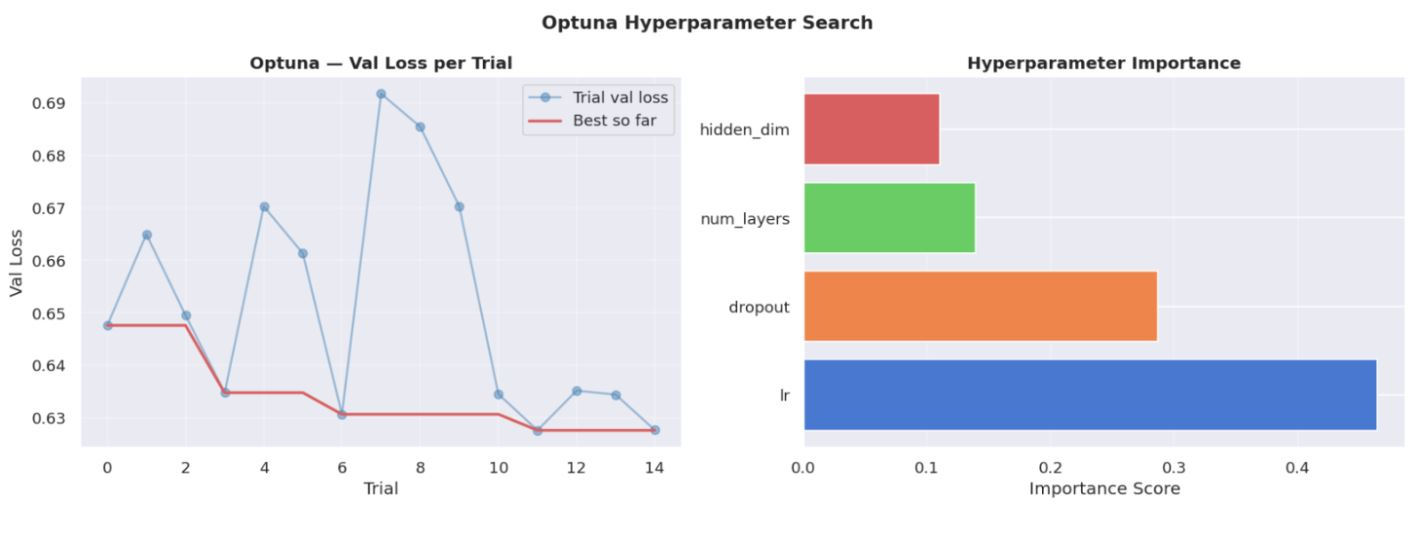

------------------------

# TEST

### Optuna Retrain

In [85]:
# Best hyperparameters found by Optuna
HIDDEN_DIM    = 128
NUM_LAYERS    = 1
DROPOUT       = 0.7
LEARNING_RATE = 0.00197

print('Retraining all models with best hyperparameters:')
print(f'  hidden_dim  : {HIDDEN_DIM}')
print(f'  num_layers  : {NUM_LAYERS}')
print(f'  dropout     : {DROPOUT}')
print(f'  lr          : {LEARNING_RATE:.5f}')

lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

print('\nTraining LSTM with best params...')
hist_lstm_cls, best_lstm_cls = train_model(
    lstm_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
torch.save(best_lstm_cls, 'best_lstm_cls_optuna.pt')

print('Training GRU with best params...')
hist_gru_cls, best_gru_cls = train_model(
    gru_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
torch.save(best_gru_cls, 'best_gru_cls_optuna.pt')

print('Training CNN with best params...')
hist_cnn_cls, best_cnn_cls = train_model(
    cnn_cls, train_cls_loader, val_cls_loader,
    task='classification', num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, val_checks=VAL_CHECKS, device=device
)
torch.save(best_cnn_cls, 'best_cnn_cls_optuna.pt')

print('\nAll models retrained with Optuna best params!')

Retraining all models with best hyperparameters:
  hidden_dim  : 128
  num_layers  : 1
  dropout     : 0.7
  lr          : 0.00197

Training LSTM with best params...

  Task: CLASSIFICATION
  Model: LSTMModel
  Device: cuda
Epoch 01/10 | Time: 6.5s | Train Loss: 0.7122 | Val Loss: 0.6347 | Val Acc: 0.6736 | Val F1: 0.6752
           Val loss improved → best model saved
Epoch 02/10 | Time: 4.9s | Train Loss: 0.5360 | Val Loss: 0.6372 | Val Acc: 0.7034 | Val F1: 0.7063
             No improvement (1/3)
Epoch 03/10 | Time: 5.4s | Train Loss: 0.4290 | Val Loss: 0.6756 | Val Acc: 0.6849 | Val F1: 0.6883
             No improvement (2/3)
Epoch 04/10 | Time: 5.0s | Train Loss: 0.3396 | Val Loss: 0.8182 | Val Acc: 0.6792 | Val F1: 0.6814
             No improvement (3/3)

 Early stopping triggered at epoch 4

Best val loss: 0.6347

Training GRU with best params...

  Task: CLASSIFICATION
  Model: GRUModel
  Device: cuda
Epoch 01/10 | Time: 5.6s | Train Loss: 0.7012 | Val Loss: 0.6369 | Val Acc

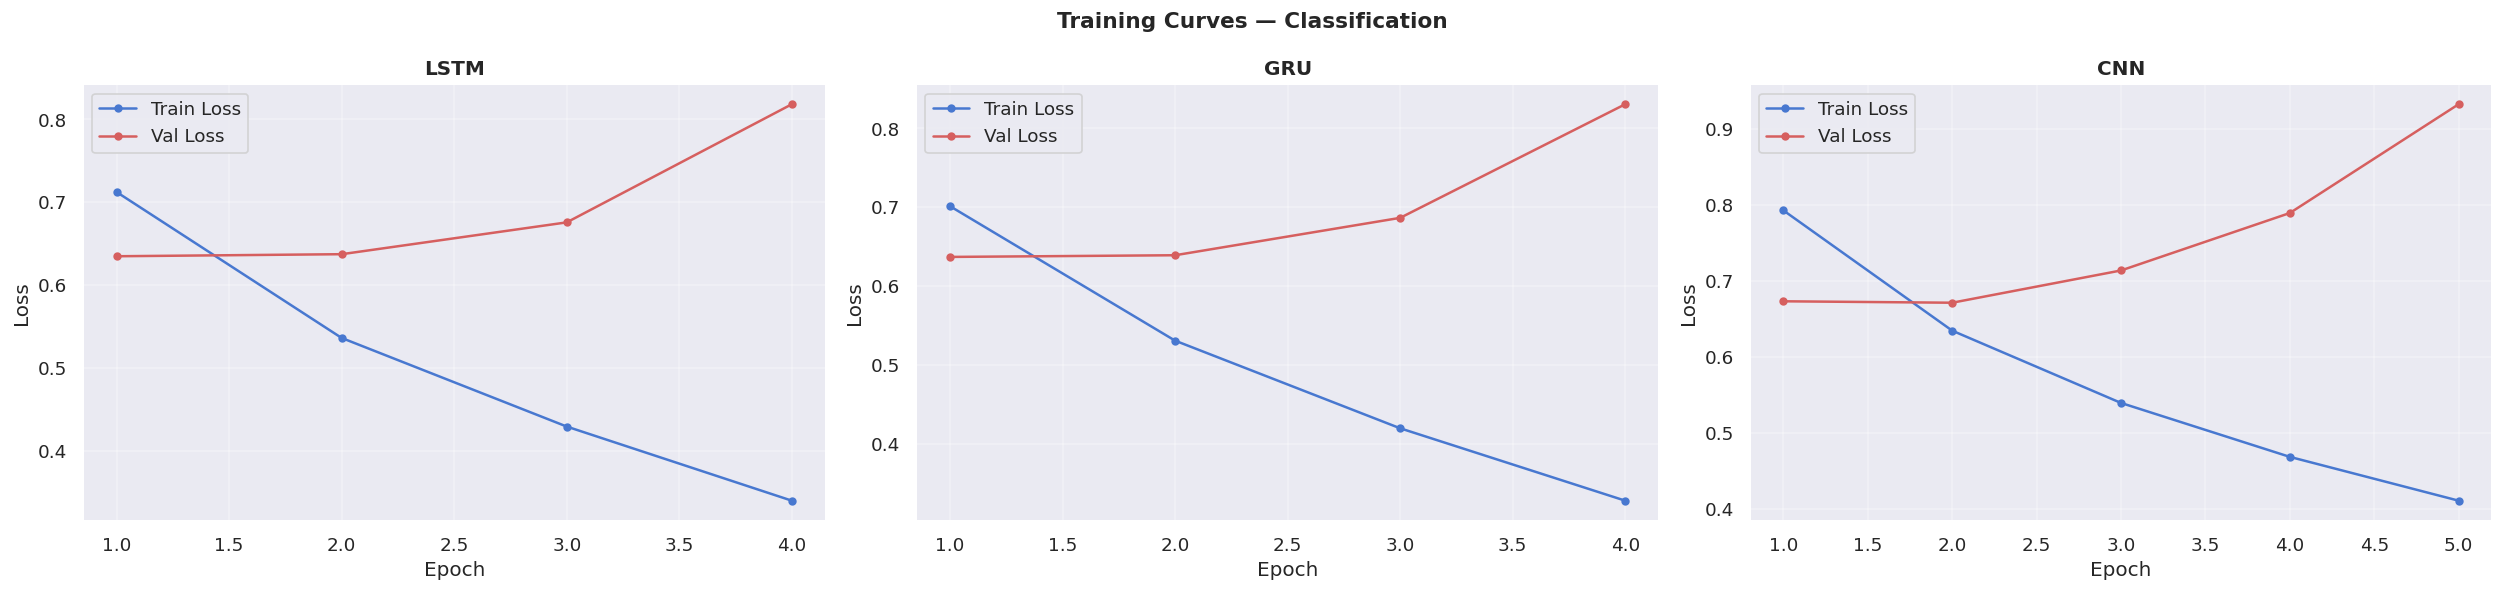

In [86]:
def plot_training_curves(histories, names, task):

    fig, axes = plt.subplots(1, len(histories), figsize=(7 * len(histories), 5))
    if len(histories) == 1:
        axes = [axes]

    for ax, history, name in zip(axes, histories, names):
        epochs = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
        ax.plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
        ax.set_title(f'{name}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Training Curves — {task.capitalize()}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Classification curves
plot_training_curves(
    [hist_lstm_cls, hist_gru_cls, hist_cnn_cls],
    ['LSTM', 'GRU', 'CNN'],
    task='classification'
)

# Regression curves
# plot_training_curves(
#     [hist_lstm_reg, hist_gru_reg, hist_cnn_reg],
#     ['LSTM', 'GRU', 'CNN'],
#     task='regression'
# )

### Manual Retrain

In [89]:
def visualize_attention(model, tweet, vocab, max_len, pad_idx, unk_idx, device):
    model.eval()
    cleaned = preprocess_tweet(tweet)
    tokens  = cleaned.split()

    sequence = pad_or_truncate(
        tokenize(cleaned, vocab, unk_idx), max_len, pad_idx
    )
    x = torch.tensor([sequence], dtype=torch.long).to(device)

    with torch.no_grad():
        embedded          = model.embedding(x)
        if hasattr(model, 'lstm'):
            out, _        = model.lstm(embedded)
        else:
            out, _        = model.gru(embedded)
        context, weights  = model.attention(out)

    weights = weights.squeeze().cpu().numpy()
    pad_len = max_len - len(tokens)
    token_weights = weights[pad_len:]

    print(f'Tweet   : {tweet}')
    print(f'Cleaned : {cleaned}')
    print(f'\nAttention weights:')
    for token, weight in zip(tokens, token_weights):
        bar = '█' * int(weight * 100)
        print(f'  {token:<15} {weight:.4f}  {bar}')

---------------

In [90]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error)

lstm_cls = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                     DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
gru_cls  = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')
cnn_cls  = CNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES,
                    DROPOUT, PAD_IDX, NUM_CLASSES, task='classification')

lstm_cls.load_state_dict(best_lstm_cls)
gru_cls.load_state_dict(best_gru_cls)
cnn_cls.load_state_dict(best_cnn_cls)

lstm_cls = lstm_cls.to(device)
gru_cls  = gru_cls.to(device)
cnn_cls  = cnn_cls.to(device)

print('Best classification weights restored.')

Best classification weights restored.


In [91]:
def evaluate_test(model, loader, criterion, device, task):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)
            loss        = criterion(predictions, y_batch)
            total_loss += loss.item()

            if task == 'classification':
                preds = torch.argmax(predictions, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
            else:
                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels)

print('evaluate_test() defined.')

evaluate_test() defined.


### Test

In [92]:
test_loss_lstm, preds_lstm, labels_cls = evaluate_test(
    lstm_cls, test_cls_loader, classification_criterion, device, 'classification'
)
test_loss_gru, preds_gru, _ = evaluate_test(
    gru_cls, test_cls_loader, classification_criterion, device, 'classification'
)
test_loss_cnn, preds_cnn, _ = evaluate_test(
    cnn_cls, test_cls_loader, classification_criterion, device, 'classification'
)

print('Test evaluation complete!')
print(f'  LSTM Test Loss: {test_loss_lstm:.4f}')
print(f'  GRU  Test Loss: {test_loss_gru:.4f}')
print(f'  CNN  Test Loss: {test_loss_cnn:.4f}')

Test evaluation complete!
  LSTM Test Loss: 0.6377
  GRU  Test Loss: 0.6291
  CNN  Test Loss: 0.6587


In [93]:
class_names = ['Negative', 'Neutral', 'Positive']

print('=' * 65)
print('  CLASSIFICATION — TEST SET RESULTS')
print('=' * 65)

results_cls = {}
for name, preds in [('LSTM', preds_lstm),
                    ('GRU',  preds_gru),
                    ('CNN',  preds_cnn)]:
    acc       = accuracy_score(labels_cls, preds)
    f1w       = f1_score(labels_cls, preds, average='weighted')
    f1m       = f1_score(labels_cls, preds, average='macro')
    f1_per    = f1_score(labels_cls, preds, average=None)
    prec_per  = __import__('sklearn.metrics', fromlist=['precision_score']).precision_score(
                    labels_cls, preds, average=None)
    rec_per   = __import__('sklearn.metrics', fromlist=['recall_score']).recall_score(
                    labels_cls, preds, average=None)

    results_cls[name] = {
        'accuracy': acc, 'f1_weighted': f1w,
        'f1_macro': f1m, 'f1_per_class': f1_per
    }

    print(f'\n  {name}:')
    print(f'    Accuracy    : {acc:.4f}')
    print(f'    F1 Weighted : {f1w:.4f}')
    print(f'    F1 Macro    : {f1m:.4f}')
    print(f'    {"Class":<12} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'    {"-"*45}')
    for i, cls in enumerate(class_names):
        print(f'    {cls:<12} {prec_per[i]:>10.4f} {rec_per[i]:>10.4f} {f1_per[i]:>10.4f}')

print('\n' + '=' * 65)

  CLASSIFICATION — TEST SET RESULTS

  LSTM:
    Accuracy    : 0.6839
    F1 Weighted : 0.6860
    F1 Macro    : 0.6749
    Class         Precision     Recall         F1
    ---------------------------------------------
    Negative         0.5266     0.7788     0.6284
    Neutral          0.8056     0.6083     0.6932
    Positive         0.6449     0.7728     0.7031

  GRU:
    Accuracy    : 0.6807
    F1 Weighted : 0.6850
    F1 Macro    : 0.6711
    Class         Precision     Recall         F1
    ---------------------------------------------
    Negative         0.4907     0.8284     0.6163
    Neutral          0.7949     0.6188     0.6959
    Positive         0.6859     0.7168     0.7010

  CNN:
    Accuracy    : 0.6973
    F1 Weighted : 0.7009
    F1 Macro    : 0.6809
    Class         Precision     Recall         F1
    ---------------------------------------------
    Negative         0.5249     0.7524     0.6184
    Neutral          0.7784     0.6802     0.7260
    Positive  

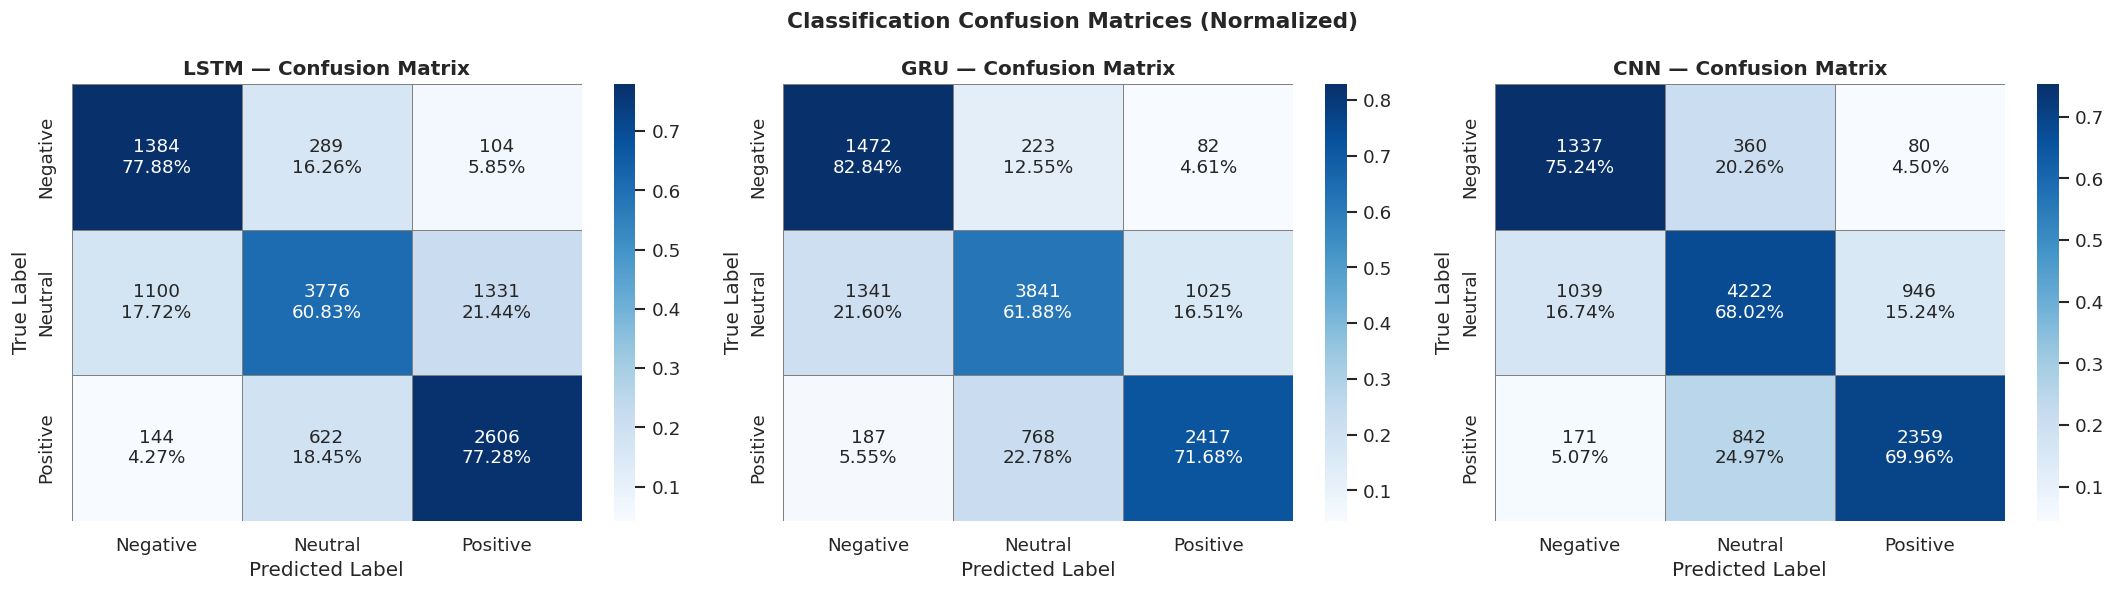

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, preds in zip(axes,
                            ['LSTM', 'GRU', 'CNN'],
                            [preds_lstm, preds_gru, preds_cnn]):
    cm = confusion_matrix(labels_cls, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n{cm_normalized[i, j]:.2%}'

    sns.heatmap(
        cm_normalized,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.5,
        linecolor='gray'
    )
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Classification Confusion Matrices (Normalized)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [95]:
print('=' * 60)
print('  FINAL CLASSIFICATION COMPARISON — TEST SET')
print('=' * 60)
print(f'\n  {"Model":<8} {"Accuracy":>10} {"F1 Weighted":>12} {"F1 Macro":>10}')
print(f'  {"-"*45}')
for name in ['LSTM', 'GRU', 'CNN']:
    r = results_cls[name]
    print(f'  {name:<8} {r["accuracy"]:>10.4f} {r["f1_weighted"]:>12.4f} {r["f1_macro"]:>10.4f}')

print(f'\n  Per-class F1:')
print(f'  {"Model":<8} {"Negative":>10} {"Neutral":>10} {"Positive":>10}')
print(f'  {"-"*45}')
for name in ['LSTM', 'GRU', 'CNN']:
    f1 = results_cls[name]['f1_per_class']
    print(f'  {name:<8} {f1[0]:>10.4f} {f1[1]:>10.4f} {f1[2]:>10.4f}')

print('=' * 60)

  FINAL CLASSIFICATION COMPARISON — TEST SET

  Model      Accuracy  F1 Weighted   F1 Macro
  ---------------------------------------------
  LSTM         0.6839       0.6860     0.6749
  GRU          0.6807       0.6850     0.6711
  CNN          0.6973       0.7009     0.6809

  Per-class F1:
  Model      Negative    Neutral   Positive
  ---------------------------------------------
  LSTM         0.6284     0.6932     0.7031
  GRU          0.6163     0.6959     0.7010
  CNN          0.6184     0.7260     0.6982


In comparison to previous tests where hyperparameters were manually modified, the models have now yielded their best results.


For the LSTM model, the percentages for the Neutral and Positive classes have improved; in the GRU model, the percentages for the Negative class have improved significantly, while the Neutral and Positive classes appear to have exchanged misclassified samples (both shifted by approximately 6% in opposite directions).


For the CNN, the Negative and Positive classes remained relatively similar, while the previous poor performance of 55% has been corrected to 68%.


Statistically, the LSTM and CNN have managed to improve their metrics relative to the GRU, making it more difficult to select a "winning" model with the current hyperparameters.


Observing the confusion matrix, it could be argued that each model is an "expert" in a different type of classification: LSTM for Positive segments, GRU for Negative segments, and CNN for Neutral segments.

# False cassifications

In [96]:
test_texts = test_cls['text'].reset_index(drop=True)

neg_as_neu_idx = [
    i for i, (true, pred) in enumerate(zip(labels_cls, preds_gru))
    if true == 0 and pred == 1
]

print(f'Negative → Neutral misclassifications: {len(neg_as_neu_idx)}')
print('\n=== Sample: Negative tweets predicted as Neutral ===\n')
for i in neg_as_neu_idx[:10]:
    print(f'  [{i}] {test_texts[i]}')
    print()

pos_as_neu_idx = [
    i for i, (true, pred) in enumerate(zip(labels_cls, preds_gru))
    if true == 2 and pred == 1
]

print(f'Positive → Neutral misclassifications: {len(pos_as_neu_idx)}')
print('\n=== Sample: Positive tweets predicted as Neutral ===\n')
for i in pos_as_neu_idx[:10]:
    print(f'  [{i}] {test_texts[i]}')
    print()

Negative → Neutral misclassifications: 223

=== Sample: Negative tweets predicted as Neutral ===

  [26] million bitcoin transactions sent nostr users not paying attention probably

  [165] federal reserve projects interest rate hikes no pivot sight probably bearish bitcoin btc report

  [172] people 2022 bitcoin

  [193] twitter recommended posts bitcoin thing no one cares tumblr recommended posts

  [254] breaking bitcoin 5 10week low sec sues binance

  [265] bitcoin getting testy

  [306] btcs governance effectively centralized bitcoin core 1 lead maintainer final say making dictatorship like dictatorships limits get away however still total perversion true decentralization

  [410] bitcoin sentiment check bearish bullish

  [487] im starting think warren buffett not going buy bitcoin

  [489] bitcoin market participants not act emotion one trader advises

Positive → Neutral misclassifications: 768

=== Sample: Positive tweets predicted as Neutral ===

  [3] central african republi

# Prediction

In [97]:
new_tweets = [
    # Negative
    ("Bitcoin is crashing hard, I lost everything investing in this garbage.", 0),
    ("Sold all my BTC, this bear market is destroying my portfolio completely.", 0),
    ("Bitcoin is a scam, whales are manipulating the price and retail loses.", 0),
    ("Another brutal red day for Bitcoin, the downtrend shows no signs of stopping.", 0),
    ("Crypto winter is here, Bitcoin dropped below support and looks terrible.", 0),

    # Neutral
    ("Bitcoin trading volume was average today with no major price movements.", 1),
    ("The Bitcoin halving is scheduled for next year according to the blockchain.", 1),
    ("Miners are currently processing around 300,000 Bitcoin transactions per day.", 1),
    ("Bitcoin has been consolidating between 40k and 45k for the past two weeks.", 1),
    ("The Bitcoin network hashrate reached a new all time high this month.", 1),

    # Positive (label = 2)
    ("Bitcoin just broke all time high, this bull run is absolutely incredible!", 2),
    ("Bought more BTC today, this dip is a massive opportunity to accumulate.", 2),
    ("Bitcoin adoption is growing fast, more institutions are buying every week.", 2),
    ("The Lightning Network is making Bitcoin transactions instant and almost free!", 2),
    ("Bitcoin is the best performing asset of the decade, hodlers are winning!", 2),
]



In [ ]:
texts  = [tweet for tweet, label in new_tweets]
labels = [label for tweet, label in new_tweets]


cleaned = [preprocess_tweet(t) for t in texts]

In [99]:
def prepare_input(cleaned_tweets, vocab, max_len, pad_idx, unk_idx, device):
        sequences = [
        pad_or_truncate(tokenize(text, vocab, unk_idx), max_len, pad_idx)
        for text in cleaned_tweets
    ]
        return torch.tensor(sequences, dtype=torch.long).to(device)

x_new    = prepare_input(cleaned, vocab, MAX_SEQ_LEN, PAD_IDX, UNK_IDX, device)
y_true   = torch.tensor(labels, dtype=torch.long).to(device)

Input tensor shape : torch.Size([15, 29])  (15 tweets × 29 tokens)
True labels        : [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]


In [100]:
def predict(model, x, device):
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        preds  = torch.argmax(logits, dim=1)
    return preds.cpu().numpy(), probs.cpu().numpy()

preds_lstm_new, probs_lstm_new = predict(lstm_cls, x_new, device)
preds_gru_new,  probs_gru_new  = predict(gru_cls,  x_new, device)
preds_cnn_new,  probs_cnn_new  = predict(cnn_cls,  x_new, device)

Predictions complete!


In [101]:
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print('=' * 100)
print('  PREDICTION RESULTS')
print('=' * 100)
print(f'  {"#":<3} {"True":<10} {"LSTM":<10} {"GRU":<10} {"CNN":<10}  Tweet')
print(f'  {"-"*90}')

for i, (tweet, true_label) in enumerate(new_tweets):
    true_name = label_names[true_label]
    lstm_name = label_names[preds_lstm_new[i]]
    gru_name  = label_names[preds_gru_new[i]]
    cnn_name  = label_names[preds_cnn_new[i]]

    lstm_mark = '✅' if preds_lstm_new[i] == true_label else '❌'
    gru_mark  = '✅' if preds_gru_new[i]  == true_label else '❌'
    cnn_mark  = '✅' if preds_cnn_new[i]  == true_label else '❌'

    print(f'  {i+1:<3} {true_name:<10} '
          f'{lstm_name:<8}{lstm_mark}  '
          f'{gru_name:<8}{gru_mark}  '
          f'{cnn_name:<8}{cnn_mark}  '
          f'{tweet[:60]}...')

print('=' * 100)

  PREDICTION RESULTS
  #   True       LSTM       GRU        CNN         Tweet
  ------------------------------------------------------------------------------------------
  1   Negative   Negative✅  Negative✅  Negative✅  Bitcoin is crashing hard, I lost everything investing in thi...
  2   Negative   Negative✅  Negative✅  Negative✅  Sold all my BTC, this bear market is destroying my portfolio...
  3   Negative   Negative✅  Negative✅  Negative✅  Bitcoin is a scam, whales are manipulating the price and ret...
  4   Negative   Negative✅  Negative✅  Negative✅  Another brutal red day for Bitcoin, the downtrend shows no s...
  5   Negative   Negative✅  Negative✅  Negative✅  Crypto winter is here, Bitcoin dropped below support and loo...
  6   Neutral    Neutral ✅  Neutral ✅  Neutral ✅  Bitcoin trading volume was average today with no major price...
  7   Neutral    Neutral ✅  Neutral ✅  Neutral ✅  The Bitcoin halving is scheduled for next year according to ...
  8   Neutral    Neutral ✅  Neu

Example 10 was once again unsuccessfully classified, as in the previous instance; however, upon examining the assigned label (Neutral) and the sentence content, the issue of poor labeling within the tweets becomes apparent—the sentence possesses a distinctly positive sentiment (which the models correctly identified).


It is highly probable that many tweets from the dataset have been misclassified in this manner.

In [102]:
print('\n=== Probability Breakdown (GRU) ===')
print(f'  {"#":<3} {"True":<10} {"P(Neg)":>8} {"P(Neu)":>8} {"P(Pos)":>8}  {"Predicted":<10}')
print(f'  {"-"*60}')

for i, (tweet, true_label) in enumerate(new_tweets):
    probs = probs_gru_new[i]
    pred  = label_names[preds_gru_new[i]]
    true  = label_names[true_label]
    mark  = '✅' if preds_gru_new[i] == true_label else '❌'
    print(f'  {i+1:<3} {true:<10} {probs[0]:>8.3f} {probs[1]:>8.3f} {probs[2]:>8.3f}  {pred:<10}{mark}')


=== Probability Breakdown (GRU) ===
  #   True         P(Neg)   P(Neu)   P(Pos)  Predicted 
  ------------------------------------------------------------
  1   Negative      0.997    0.003    0.000  Negative  ✅
  2   Negative      0.930    0.060    0.011  Negative  ✅
  3   Negative      0.990    0.009    0.000  Negative  ✅
  4   Negative      0.813    0.119    0.069  Negative  ✅
  5   Negative      0.974    0.016    0.010  Negative  ✅
  6   Neutral       0.250    0.514    0.236  Neutral   ✅
  7   Neutral       0.012    0.757    0.231  Neutral   ✅
  8   Neutral       0.257    0.606    0.136  Neutral   ✅
  9   Neutral       0.156    0.524    0.321  Neutral   ✅
  10  Neutral       0.012    0.227    0.761  Positive  ❌
  11  Positive      0.001    0.007    0.993  Positive  ✅
  12  Positive      0.009    0.176    0.815  Positive  ✅
  13  Positive      0.002    0.041    0.957  Positive  ✅
  14  Positive      0.004    0.119    0.877  Positive  ✅
  15  Positive      0.000    0.005    0.995  P

In [103]:
print('\n=== Accuracy on 15 New Tweets ===')
for name, preds in [('LSTM', preds_lstm_new),
                    ('GRU',  preds_gru_new),
                    ('CNN',  preds_cnn_new)]:
    correct = sum(p == t for p, t in zip(preds, labels))
    acc     = correct / len(labels)

    # Per class accuracy
    neg_correct = sum(p == t for p, t in zip(preds, labels) if t == 0)
    neu_correct = sum(p == t for p, t in zip(preds, labels) if t == 1)
    pos_correct = sum(p == t for p, t in zip(preds, labels) if t == 2)

    print(f'\n  {name}:')
    print(f'    Overall  : {correct}/15  ({acc:.1%})')
    print(f'    Negative : {neg_correct}/5')
    print(f'    Neutral  : {neu_correct}/5')
    print(f'    Positive : {pos_correct}/5')


=== Accuracy on 15 New Tweets ===

  LSTM:
    Overall  : 14/15  (93.3%)
    Negative : 5/5
    Neutral  : 4/5
    Positive : 5/5

  GRU:
    Overall  : 14/15  (93.3%)
    Negative : 5/5
    Neutral  : 4/5
    Positive : 5/5

  CNN:
    Overall  : 13/15  (86.7%)
    Negative : 5/5
    Neutral  : 3/5
    Positive : 5/5
